## t-Distributed Stochastic Neighbor Embedding

In [ ]:
import glob
import sys
import os
import copy
import math
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import svm
from matplotlib.ticker import NullFormatter
from sklearn import manifold, datasets
from time import time

In [ ]:
from numpy import set_printoptions
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### inecesario

In [ ]:
dict_class = {
    '3': 'Forest formation',
    '4': 'Savanna Formation',
    '12': 'Grassland',
    '15': 'Pasture',
    '18': 'Agriculture',
    '22': 'Non vegetated Area',
#     '29': 'Rocky Outcrop',
    '33': 'Water'
}

In [ ]:
dict_class ={
    'class': ['Forest formation', 'Savanna Formation', 'Grassland', 'Pasture', 'Agriculture', 'Non vegetated Area', 'Water'],
    'samples': [12364, 91776, 8899, 4765, 10246, 2002, 213]
}
df_graf = pd.DataFrame.from_dict(dict_class)
df_graf

,class,samples
0,Forest formation,12364
1,Savanna Formation,91776
2,Grassland,8899
3,Pasture,4765
4,Agriculture,10246
5,Non vegetated Area,2002
6,Water,213


In [ ]:
import plotly.express as px

In [ ]:
# Create an array with the colors you want to use
colors = ["#006400","#00ff00","#B8AF4F","#FFD966","#E974ED","#EA9999","#0000FF"]
# Set your custom color palette
sns.set_palette(sns.color_palette(colors))


In [ ]:
fig = px.pie(
        df_graf,
        values='samples',
        names='class',
        # title= "Distribuição de amostras",
        color_discrete_sequence = colors
        )
fig.update_layout(
    title=dict(text="Distribuição de amostras", font=dict(size=32), automargin=True, yref='paper'),
    width = 500
)
fig.update_traces(textinfo='value+percent')
fig.show()

In [ ]:
df = px.data.gapminder().query("year == 2007")
fig = px.bar(df, y="continent", x="pop", color="continent", orientation="h", hover_name="country",
             color_discrete_map={
                "Europe": "red",
                "Asia": "green",
                "Americas": "blue",
                "Oceania": "goldenrod",
                "Africa": "magenta"},
             title="Explicit color mapping")

fig.show()

### loading Data from drive

In [ ]:
# Cloud authentication.
from google.colab import auth
auth.authenticate_user()
from google.colab import drive

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
pathBase = '/content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/'
!ls /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan

pontos_trained_v1_2018_Pant.csv  pontos_train_S2_3_2022_21.csv	pontos_train_S2_3_2022_3.csv
pontos_train_S2_3_2022_12.csv	 pontos_train_S2_3_2022_33.csv	pontos_train_S2_3_2022_4.csv


In [ ]:
# read many files CSVs
manyfile = True

In [ ]:
name_table = 'pontos_trained_v1_2018_Pant.csv'
INPUT_path = os.path.join(pathBase, name_table)
print("reading files from >> ", INPUT_path)


reading files from >>  /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/pontos_trained_v1_2018_Pant.csv


In [ ]:
if manyfile:
    allfiles = glob.glob(os.path.join(pathBase, "*.csv"))
    df_from_each_file = []
    zz = 0
    for cc, nfile in enumerate(allfiles):
        if 'pontos_train_S2_3_2022' in nfile:
            print('lindo de {} ==> {}'.format(cc ,nfile))

            newdf = pd.read_csv(nfile)
            newdf = newdf.drop(['system:index','.geo'], axis=1)
            df_from_each_file.append(newdf)
            # print("coluns ", newdf.columns)
            print("shape tables ", newdf.shape)
            zz += 1

    print("leiu {} de {} no folder".format(zz, len(allfiles)))

    concat_df  = pd.concat(df_from_each_file, ignore_index=True) #
    print("temos {} filas ".format(concat_df.shape))
    concat_df.head()

else:
    print(f'lindo de {1} ==> {INPUT_path}')
    concat_df = pd.read_csv(INPUT_path)
    concat_df = concat_df.drop(['system:index','.geo'], axis=1)
    print("shape from table ", concat_df.shape)
    print("list colunas ", concat_df.columns)
    print("show the first 5 rows from table")
    print(concat_df.head())


lindo de 1 ==> /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/pontos_train_S2_3_2022_21.csv
shape tables  (2568, 145)
lindo de 2 ==> /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/pontos_train_S2_3_2022_12.csv
shape tables  (3350, 145)
lindo de 3 ==> /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/pontos_train_S2_3_2022_4.csv
shape tables  (2933, 145)
lindo de 4 ==> /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/pontos_train_S2_3_2022_3.csv
shape tables  (2079, 145)
lindo de 5 ==> /content/drive/MyDrive/mapbiomas/featureSelection/CSV_ROIs_Pan/pontos_train_S2_3_2022_33.csv
shape tables  (1943, 145)
leiu 5 de 6 no folder
temos (12873, 145) filas 


In [ ]:
lstColunas = [kk for kk in concat_df.columns]
print("numero de variaveis ", len(lstColunas))
step = 5
# for ii in range(0, len(lstColunas), step):
#     print(lstColunas[ii: ii + step])
text = ''
for cc, col in enumerate(lstColunas):
    text += '"' + str(col) + '",'
    if (cc + 1) % 5 == 0:
        print(text)
        text = ""

print(text)

numero de variaveis  145
"GEDI","blue_median","blue_median_dry","blue_median_wet","blue_min",
"blue_stdDev","cai_median","cai_median_dry","cai_stdDev","cloud_amp",
"cloud_max","cloud_median","cloud_median_dry","cloud_median_wet","cloud_min",
"cloud_stdDev","evi2_amp","evi2_median","evi2_median_dry","evi2_median_wet",
"evi2_stdDev","gcvi_median","gcvi_median_dry","gcvi_median_wet","gcvi_stdDev",
"green_median","green_median_dry","green_median_texture","green_median_wet","green_min",
"green_stdDev","gv_amp","gv_max","gv_median","gv_median_dry",
"gv_median_wet","gv_min","gv_stdDev","gvs_amp","gvs_max",
"gvs_median","gvs_median_dry","gvs_median_wet","gvs_min","gvs_stdDev",
"hallcover_median","hallcover_stdDev","latitude","longitude","nddi_dry",
"nddi_wet","ndfi_amp","ndfi_max","ndfi_median","ndfi_median_dry",
"ndfi_median_wet","ndfi_min","ndfi_stdDev","ndvi_amp","ndvi_median",
"ndvi_median_dry","ndvi_median_wet","ndvi_stdDev","ndwi_amp","ndwi_median",
"ndwi_median_dry","ndwi_median_wet","n

In [ ]:
columns_features = lstColunas
columns_features.remove('reference')

In [ ]:
concat_df.describe()

,GEDI,blue_median,blue_median_dry,blue_median_wet,blue_min,blue_stdDev,cai_median,cai_median_dry,cai_stdDev,cloud_amp,...,swir1_stdDev,swir2_median,swir2_median_dry,swir2_median_wet,swir2_min,swir2_stdDev,wefi_amp,wefi_median,wefi_median_wet,wefi_stdDev
count,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,1.287300e+04,12873.000000,...,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000,12873.000000
mean,2.977006,958.289521,1062.031617,906.382817,844.654781,142.186825,15023.211140,15510.484658,7.186178e+02,8.402470,...,335.722986,952.712344,1275.186981,753.966830,529.897771,256.739843,41.506719,49.300396,60.501282,9.953002
std,4.502099,110.010708,139.285170,100.226695,84.811570,70.038658,789.291602,808.089793,1.112185e+04,7.124611,...,188.529698,552.231440,670.020582,430.220375,331.256714,157.988017,19.613389,17.436633,22.245991,5.581982
min,0.000000,743.000000,757.000000,718.000000,0.000000,27.000000,13436.000000,12923.000000,9.900000e+01,2.000000,...,19.000000,22.000000,32.000000,13.000000,0.000000,11.000000,2.000000,0.000000,0.000000,0.000000
25%,0.000000,879.000000,964.000000,837.000000,786.000000,113.000000,14428.000000,14986.000000,3.910000e+02,6.000000,...,200.000000,584.000000,810.000000,507.000000,293.000000,144.000000,28.000000,41.000000,52.000000,6.000000
50%,0.000000,934.000000,1051.000000,886.000000,832.000000,137.000000,14942.000000,15465.000000,5.010000e+02,7.000000,...,304.000000,837.000000,1218.000000,679.000000,505.000000,230.000000,40.000000,52.000000,64.000000,9.000000
75%,5.000000,1023.000000,1149.000000,956.000000,889.000000,160.000000,15491.000000,15991.000000,6.380000e+02,9.000000,...,439.000000,1286.000000,1726.000000,967.000000,700.000000,342.000000,54.000000,60.000000,74.000000,13.000000
max,23.000000,1981.000000,1932.000000,1972.000000,1499.000000,2077.000000,20369.000000,20485.000000,1.090885e+06,196.000000,...,1650.000000,4415.000000,4240.000000,4358.000000,2622.000000,1489.000000,158.000000,122.000000,156.000000,50.000000


In [ ]:
# verificar o número de classes na tabela juntadas
concat_df['reference'].unique()

array([21, 12,  4,  3, 33])

In [ ]:
columns_features = [
            "GEDI","blue_median","blue_median_dry","blue_median_wet","blue_min",
            "blue_stdDev","cai_median","cai_median_dry","cai_stdDev","cloud_amp",
            "cloud_max","cloud_median","cloud_median_dry","cloud_median_wet","cloud_min",
            "cloud_stdDev","evi2_amp","evi2_median","evi2_median_dry","evi2_median_wet",
            "evi2_stdDev","gcvi_median","gcvi_median_dry","gcvi_median_wet","gcvi_stdDev",
            "green_median","green_median_dry","green_median_texture","green_median_wet","green_min",
            "green_stdDev","gv_amp","gv_max","gv_median","gv_median_dry",
            "gv_median_wet","gv_min","gv_stdDev","gvs_amp","gvs_max",
            "gvs_median","gvs_median_dry","gvs_median_wet","gvs_min","gvs_stdDev",
            "hallcover_median","hallcover_stdDev","latitude","longitude","nddi_dry",
            "nddi_wet","ndfi_amp","ndfi_max","ndfi_median","ndfi_median_dry",
            "ndfi_median_wet","ndfi_min","ndfi_stdDev","ndvi_amp","ndvi_median",
            "ndvi_median_dry","ndvi_median_wet","ndvi_stdDev","ndwi_amp","ndwi_median",
            "ndwi_median_dry","ndwi_median_wet","ndwi_stdDev","nir_median","nir_median_dry",
            "nir_median_wet","nir_min","nir_stdDev","npv_amp","npv_max",
            "npv_median","npv_median_dry","npv_median_wet","npv_min","npv_stdDev",
            "pri_median","pri_median_dry","pri_median_wet","red_edge_1_median","red_edge_1_median_dry",
            "red_edge_1_median_wet","red_edge_1_min","red_edge_1_stdDev","red_edge_2_median","red_edge_2_median_dry",
            "red_edge_2_median_wet","red_edge_2_min","red_edge_2_stdDev","red_edge_3_median","red_edge_3_median_dry",
            "red_edge_3_median_wet","red_edge_3_min","red_edge_3_stdDev","red_edge_4_median","red_edge_4_median_dry",
            "red_edge_4_median_wet","red_edge_4_min","red_edge_4_stdDev","red_median","red_median_dry",
            "red_median_wet","red_min","red_stdDev","savi_median",
            "savi_median_dry","savi_median_wet","savi_stdDev","sefi_median","sefi_median_dry",
            "sefi_stdDev","shade_amp","shade_max","shade_median","shade_median_dry",
            "shade_median_wet","shade_min","shade_stdDev","slope","soil_amp",
            "soil_max","soil_median","soil_median_dry","soil_median_wet","soil_min",
            "soil_stdDev","swir1_median","swir1_median_dry","swir1_median_wet","swir1_min",
            "swir1_stdDev","swir2_median","swir2_median_dry","swir2_median_wet","swir2_min",
            "swir2_stdDev","wefi_amp","wefi_median","wefi_median_wet","wefi_stdDev"
        ]
classe = "reference"
print(len(columns_features))
# featureTest = ['blue', 'blue_1','blue_median', 'blue_median_dry', 'blue_stdDev']
# featureTest2 = ['iia', 'iia_median', 'iia_median_dry']

144


In [ ]:
len(columns_features)

124

In [ ]:
feature_imp = []
bloco1 = ['gv_median','npv_median','soil_median','npv_amp','swir1_median']

### Plot variaveis

In [ ]:
# ver distribuição de pontos por classe de referencia
conta = concat_df[[classe, columns_features[0]]].groupby(classe).count()
conta

,GEDI
reference,
3,2079
4,2933
12,3350
21,2568
33,1943


In [ ]:
valquant = conta[columns_features[0]].values
valquant

array([2079, 2933, 3350, 2568, 1943])

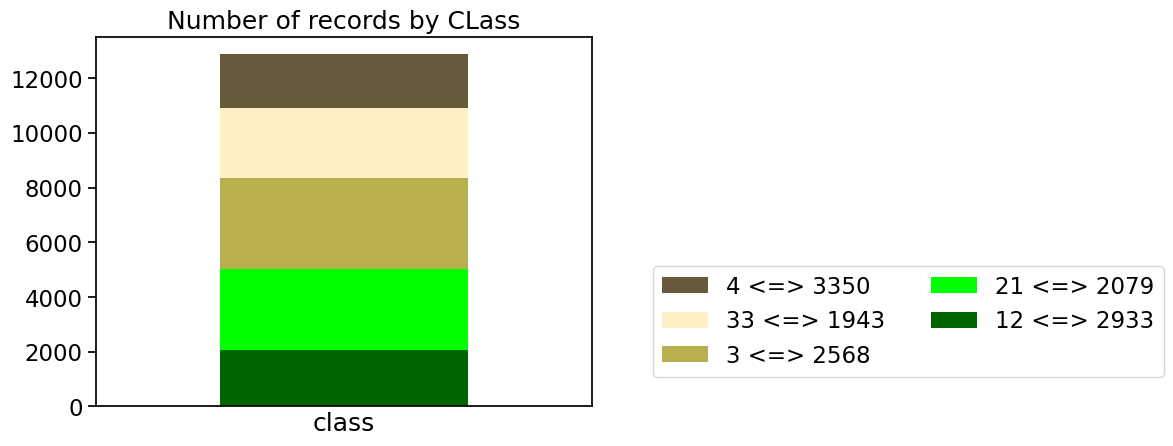

In [ ]:
concat_df.assign(dummy = 1).groupby(
  ['dummy',classe]
).size().to_frame().unstack().plot(kind='bar',stacked=True,legend=False)
plt.title('Number of records by CLass')
# other it'll show up as 'dummy'
plt.xlabel('class')
# disable ticks in the x axis
plt.xticks([])
# fix the legend
current_handles, _ = plt.gca().get_legend_handles_labels()
reversed_handles = reversed(current_handles)

labels =[str(kk) + ' <=> '+ str(valquant[cc]) for cc,  kk in enumerate(concat_df[classe].unique())]
labels.sort(reverse=True)
plt.legend(reversed_handles,labels,loc='lower left',bbox_to_anchor=(1.1, 0.05), ncol=2)
plt.show()


In [ ]:
# Create an array with the colors you want to use
# colors = ["#006400","#00ff00","#B8AF4F","#FFD966","#E974ED","#EA9999","#665a3a"]
colors = ["#006400","#00ff00","#B8AF4F","#ffefc3","#665a3a"]
# Set your custom color palette
sns.set_palette(sns.color_palette(colors))

dict_class = {
    '3': 'Forest formation',
    '4': 'Savanna Formation',
    '12': 'Grassland',
    '15': 'Pasture',
    '18': 'Agriculture',
    '21': 'mosaico de uso',
    '22': 'Non vegetated Area',
    '33': 'Water'
}
markersplot = ["o","s","^","p","X"]  # ,"<", ,"*","d"
lstCover = ['Forest formation','Savanna Formation','Grassland', 'mosaico de uso','Water']


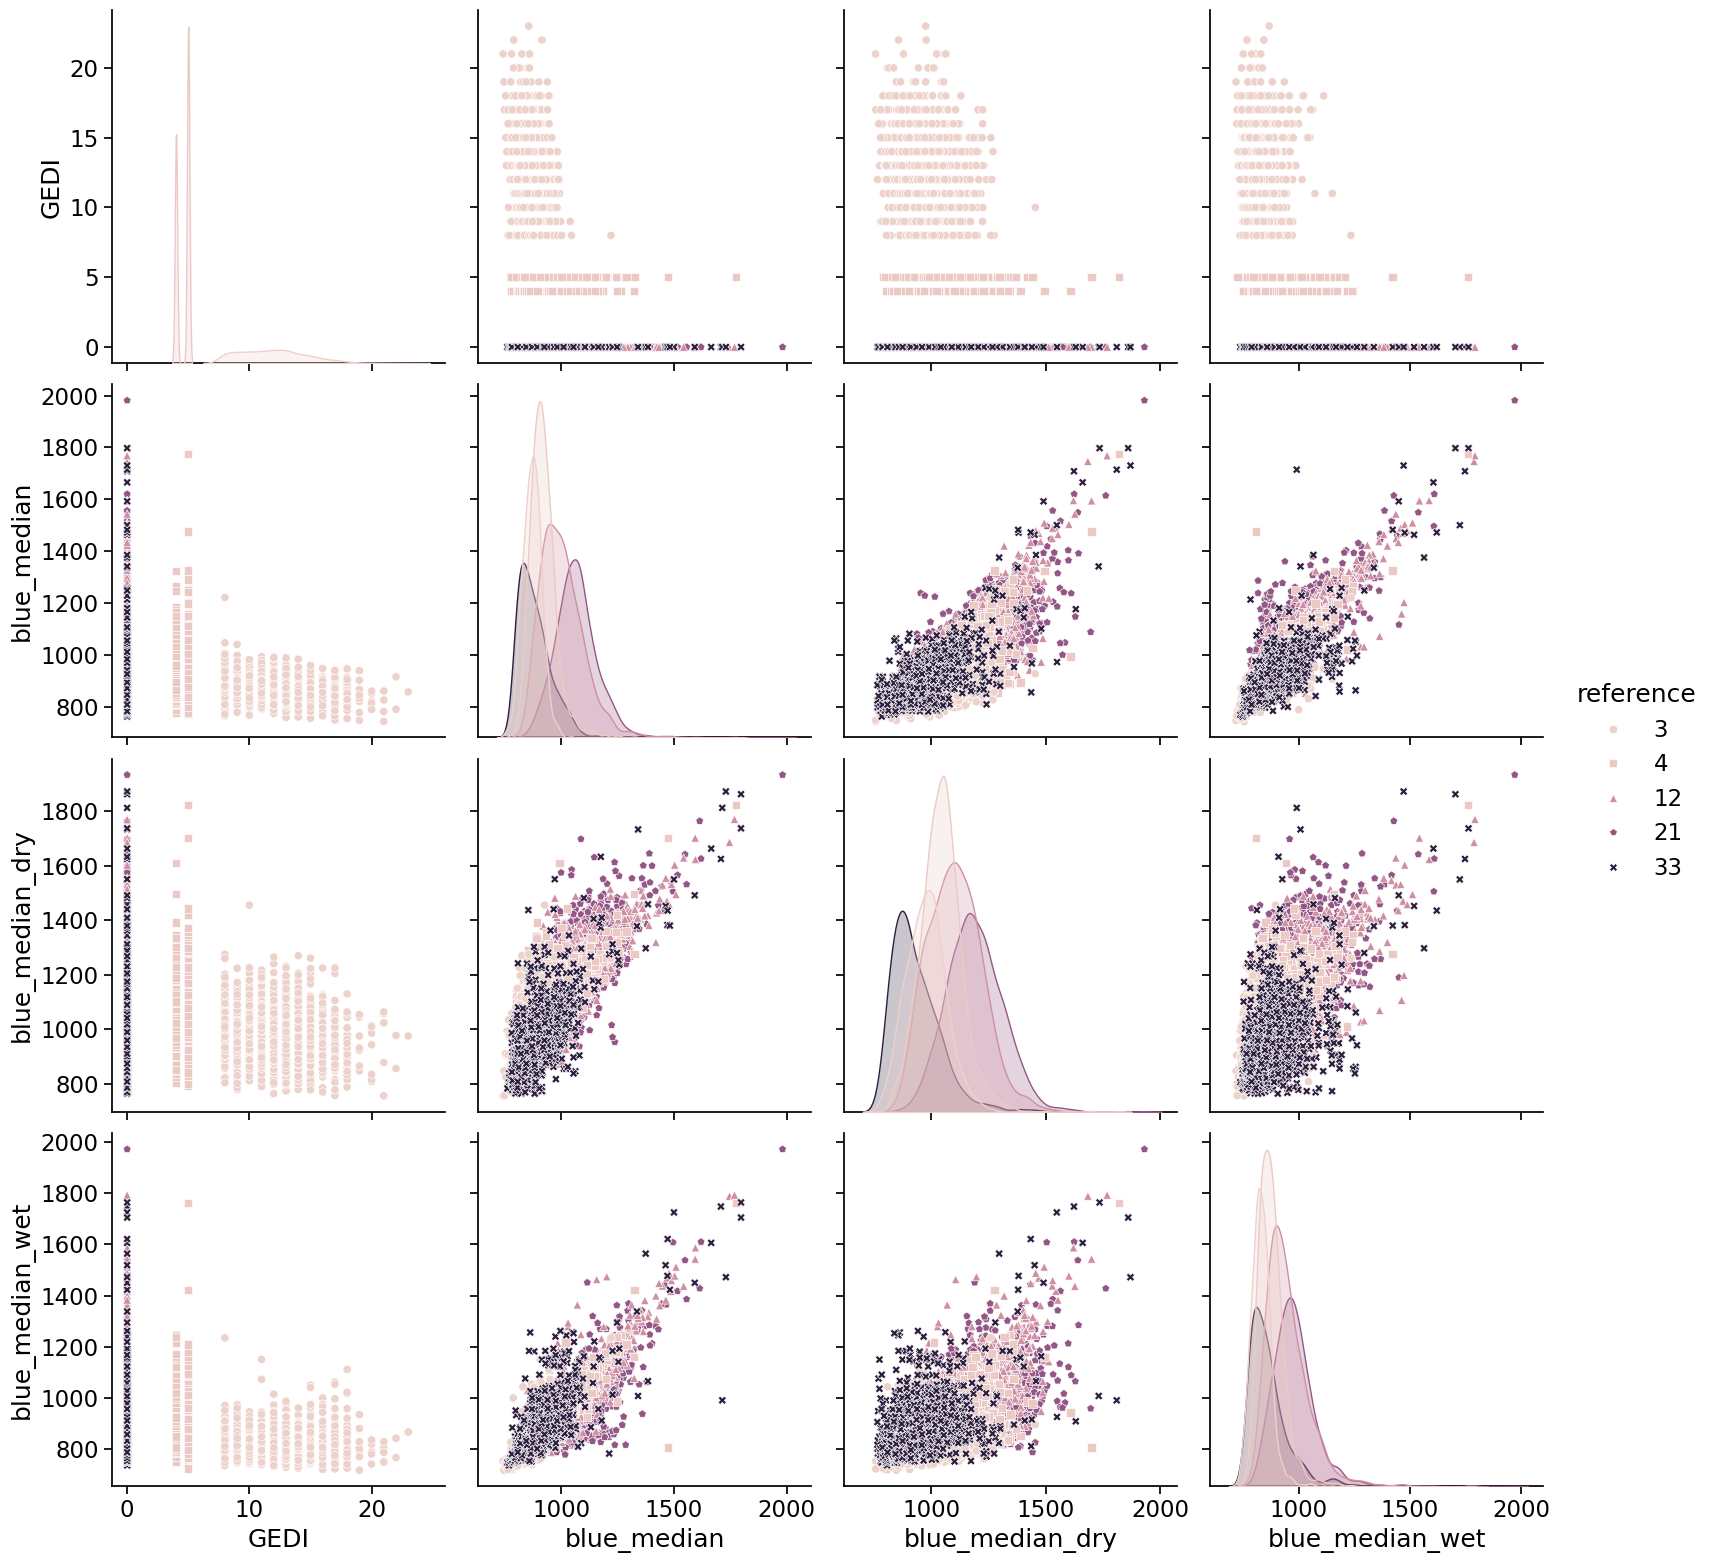

In [ ]:
bloco1 = columns_features[:4]
sns.pairplot(vars=bloco1, data= concat_df, hue=classe, height=4, markers= markersplot)
sns.set_context("notebook", font_scale=1.5)  #

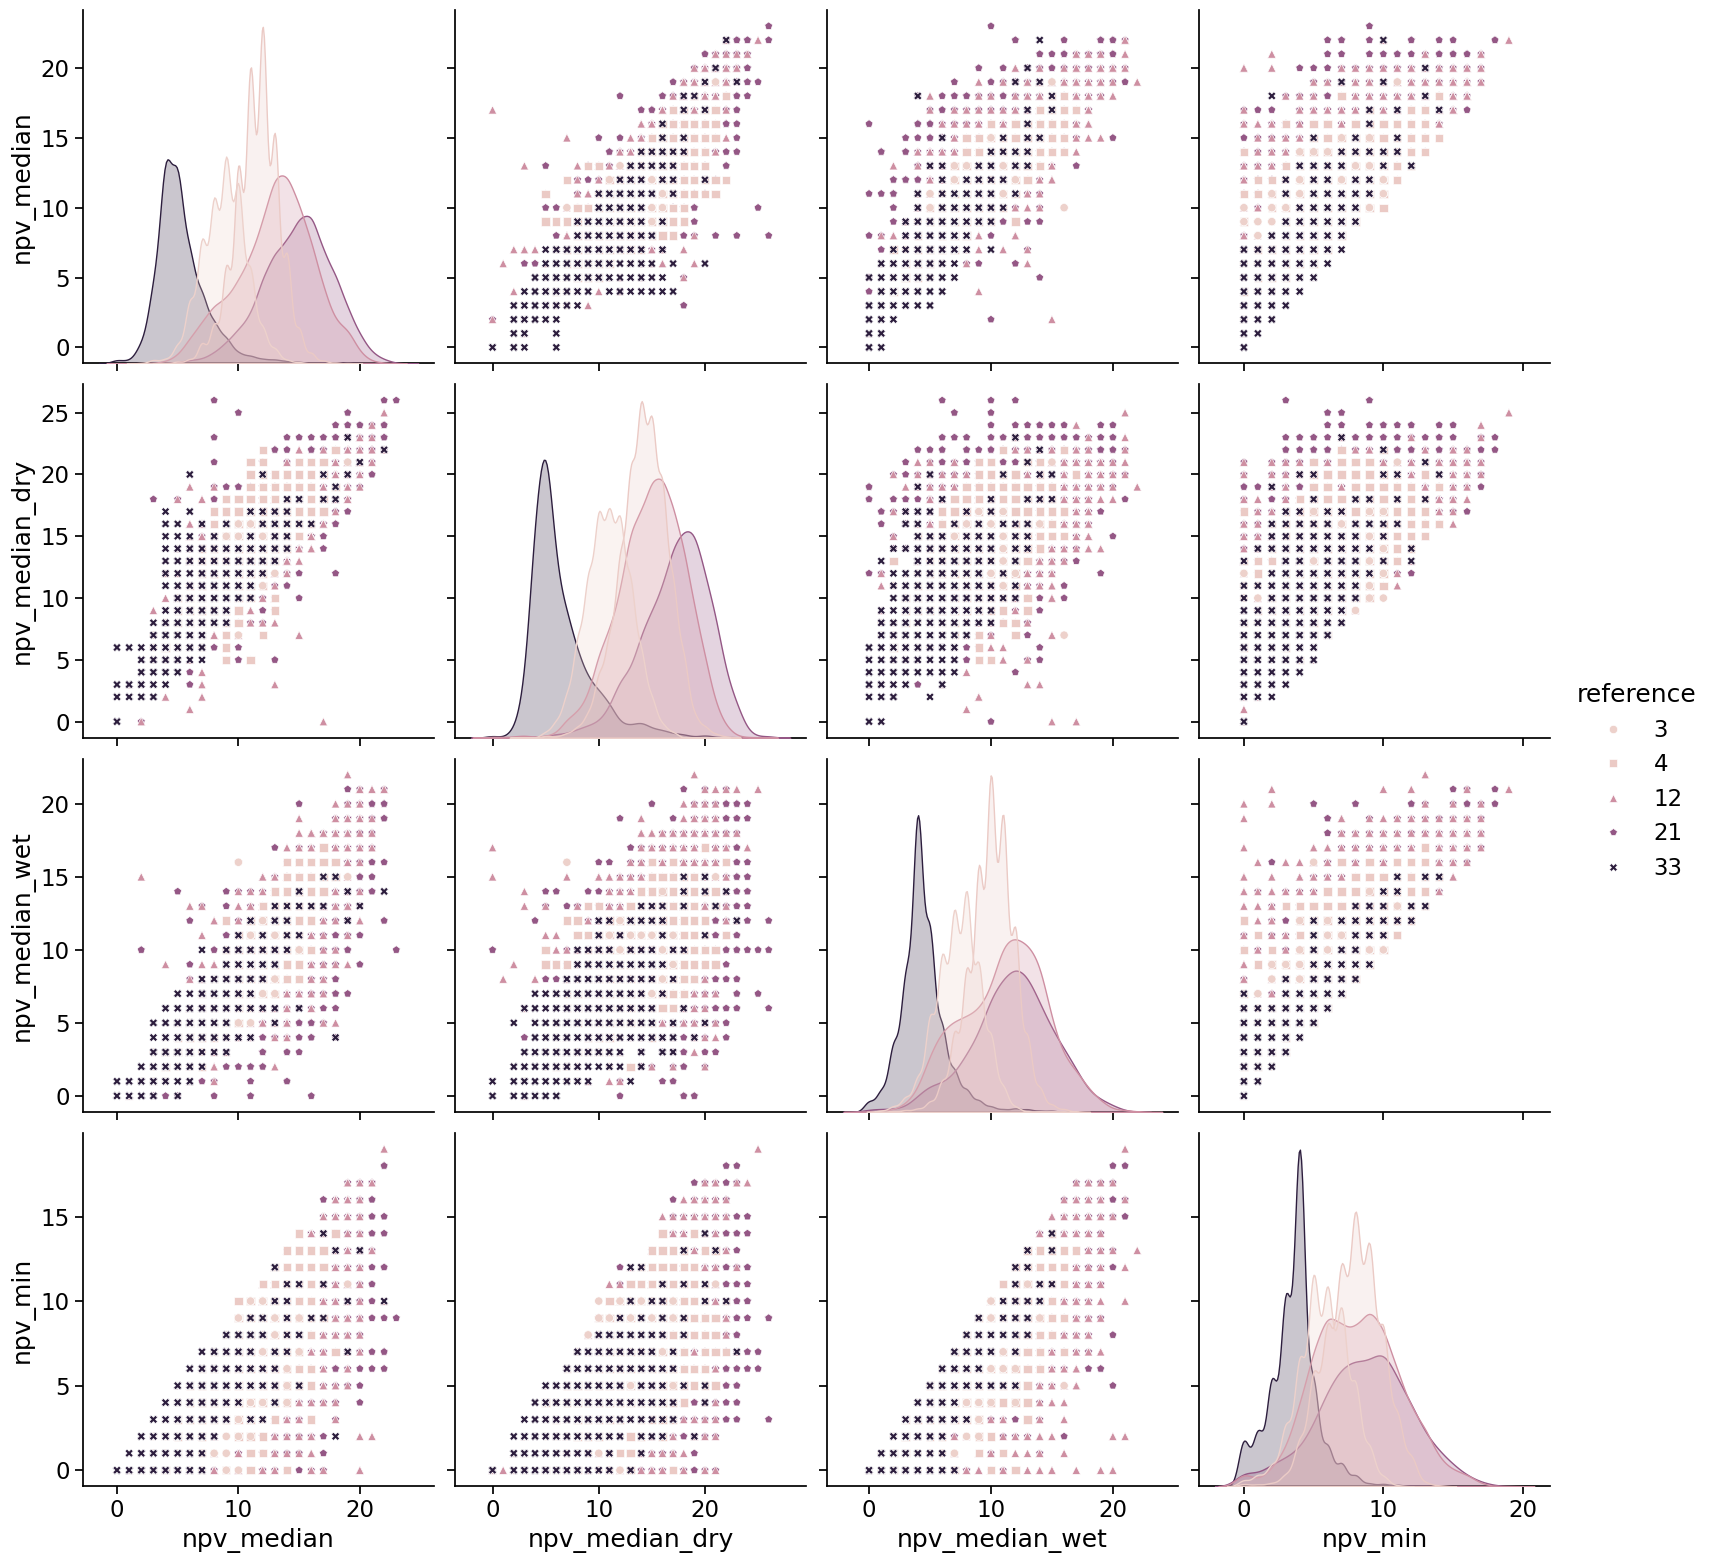

In [ ]:
bloco1 = ["npv_median","npv_median_dry","npv_median_wet","npv_min",]
sns.pairplot(vars=bloco1, data= concat_df, hue= classe, height=4, markers= markersplot)
sns.set_context("notebook", font_scale=1.5)  #

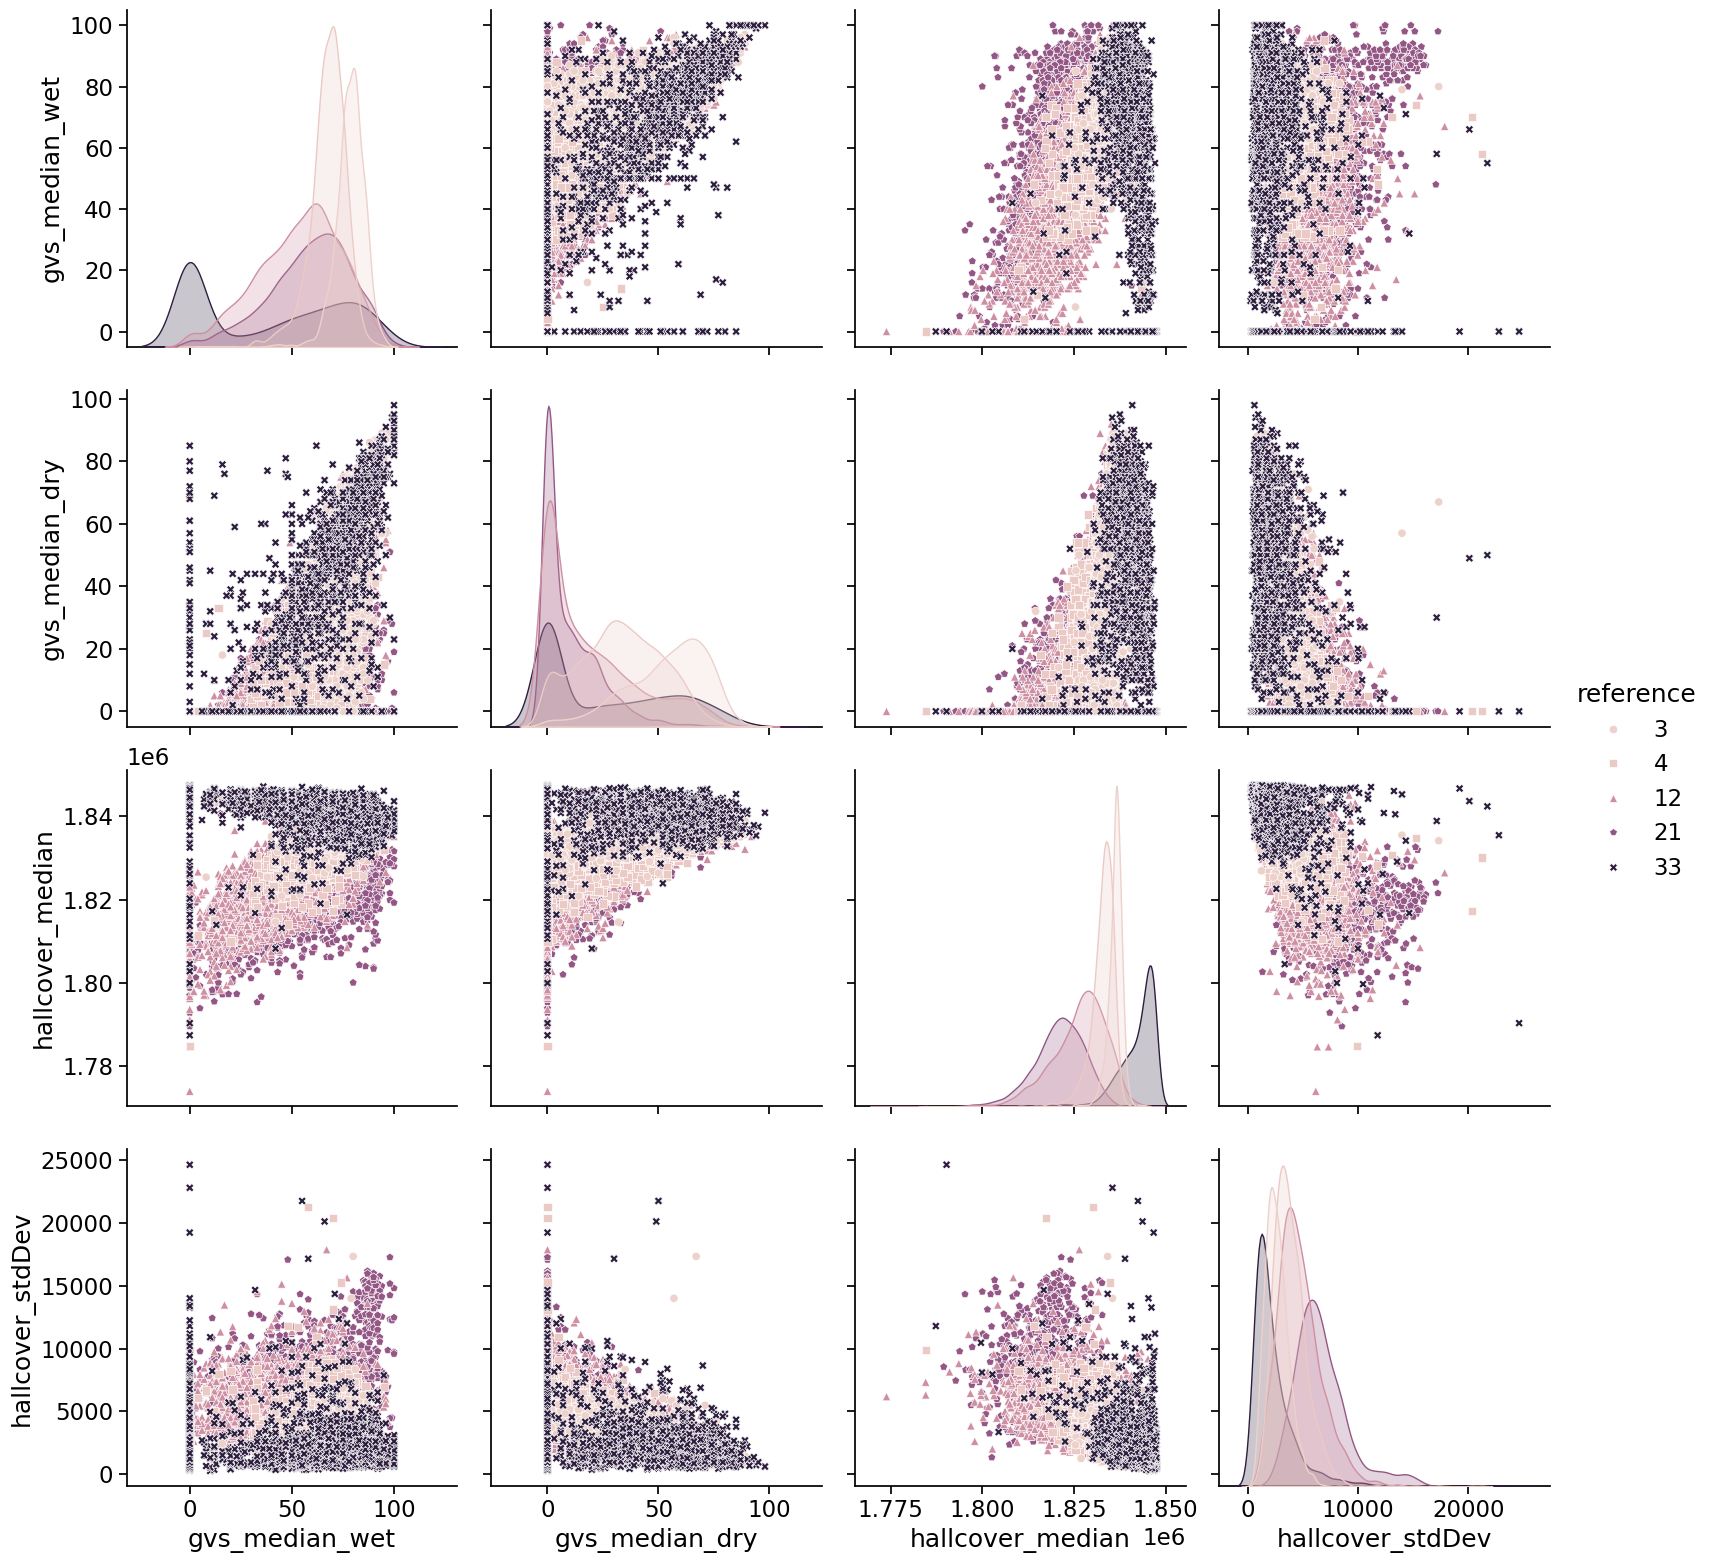

In [ ]:
bloco1 = ["gvs_median_wet","gvs_median_dry", "hallcover_median","hallcover_stdDev"]
sns.pairplot(vars=bloco1, data= concat_df, hue=classe, height=4, markers= markersplot)
sns.set_context("notebook", font_scale=1.5)  #

In [ ]:
from random import randint
colunas_index = [
                    "nddi_wet","ndfi_amp","ndfi_max","ndfi_median",
                    "ndfi_median_wet","ndfi_min","ndfi_stdDev","ndvi_amp",
                    "ndvi_median_dry","ndvi_median_wet","ndvi_stdDev","ndwi_amp",
                    "ndwi_median_dry","ndwi_median_wet","ndwi_stdDev","nir_median",
                    "nir_median_wet","nir_min","nir_stdDev","npv_amp"
                ]

In [ ]:
def ploting_violin_rois_Class_index (featA):

    fig , axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(18, 9))
    # Set your custom color palette
    sns.set_palette(sns.color_palette(colors))
    ladoA = sns.boxplot(x= classe, y=featA, data=concat_df, ax= axes[0])  # , palette="Set3"
    ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
                        scale="count", inner="quartile")
    # sns.catplot(x="label", y="shade", data=ndf, palette="Set3")  # ax= axes[2],
    ladoA.set_xlabel("CLASS",fontsize=16)
    ladoA.set_ylabel(featA,fontsize=16)
    ladoB.set_xlabel("CLASS",fontsize=16)
    ladoB.set_ylabel(featA,fontsize=16)
    ladoA.set_xticklabels(lstCover, rotation=45)
    ladoB.set_xticklabels(lstCover, rotation=45)

    plt.suptitle('Plot ROIs class in {}'.format(featA), fontsize=24)
    plt.show()

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


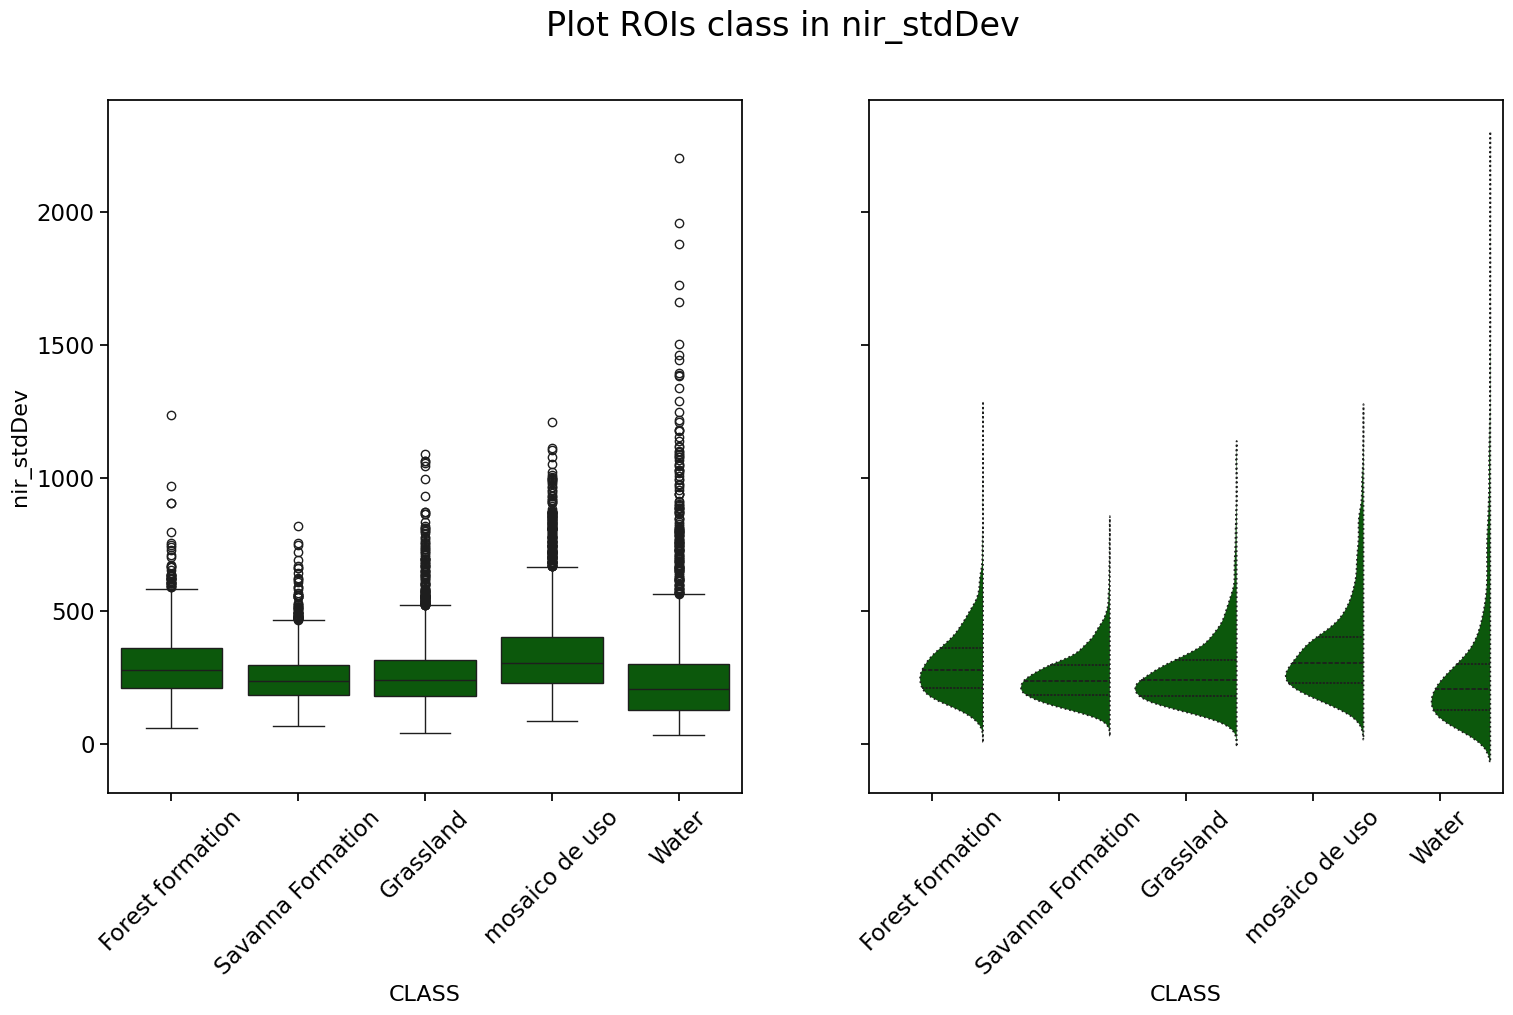

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


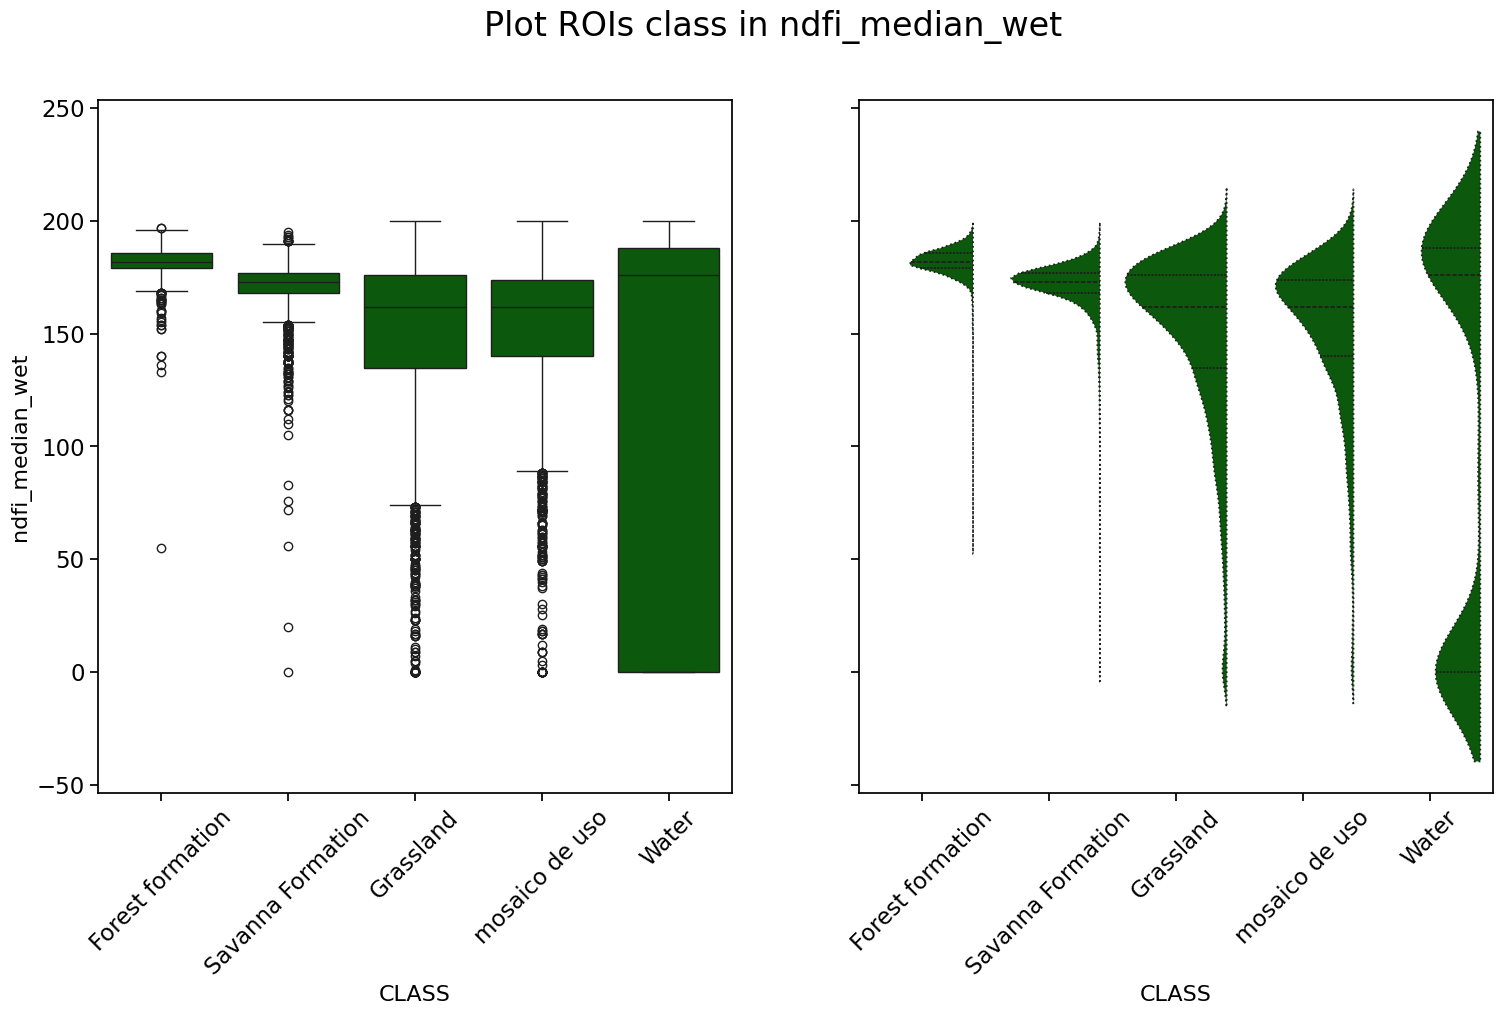

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


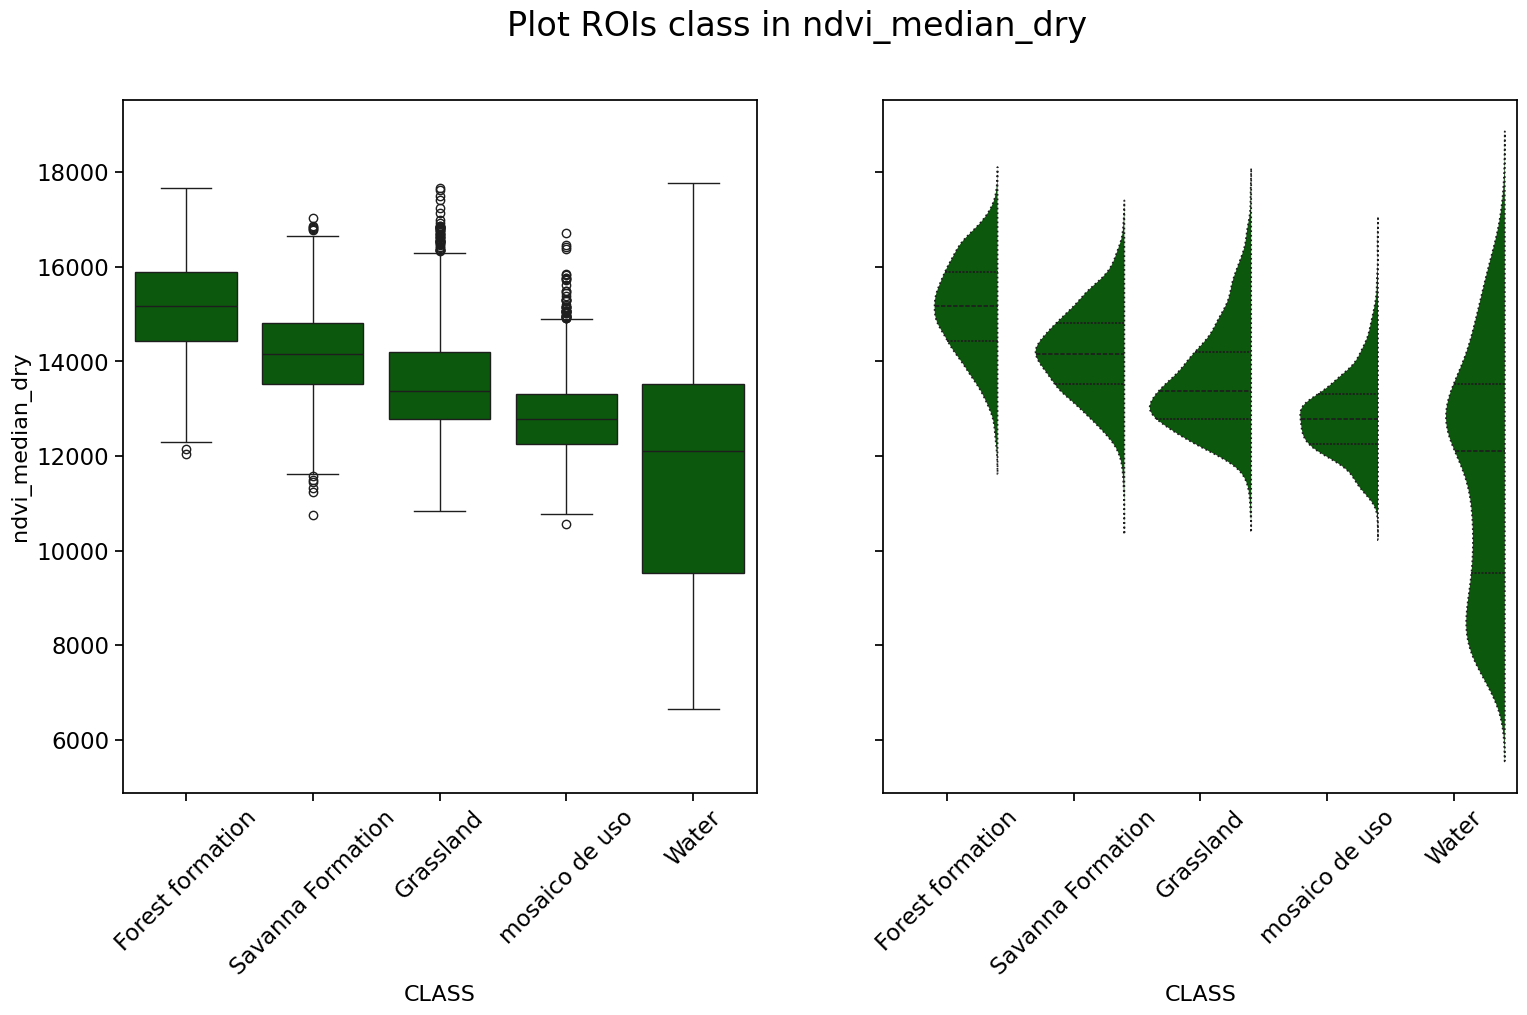

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


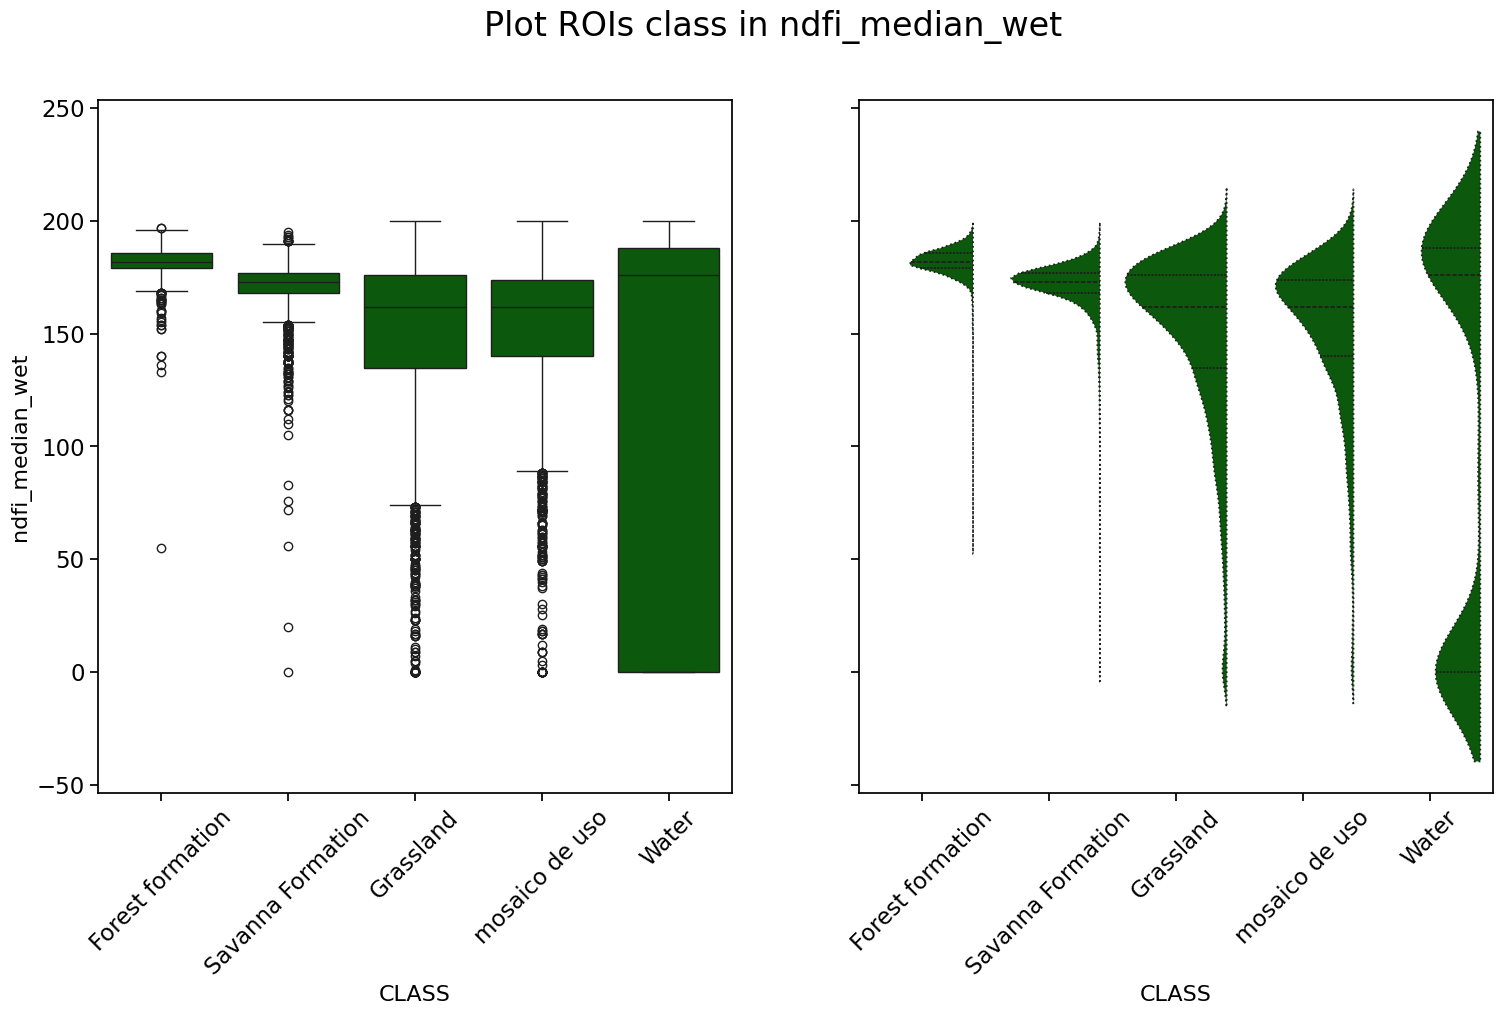

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


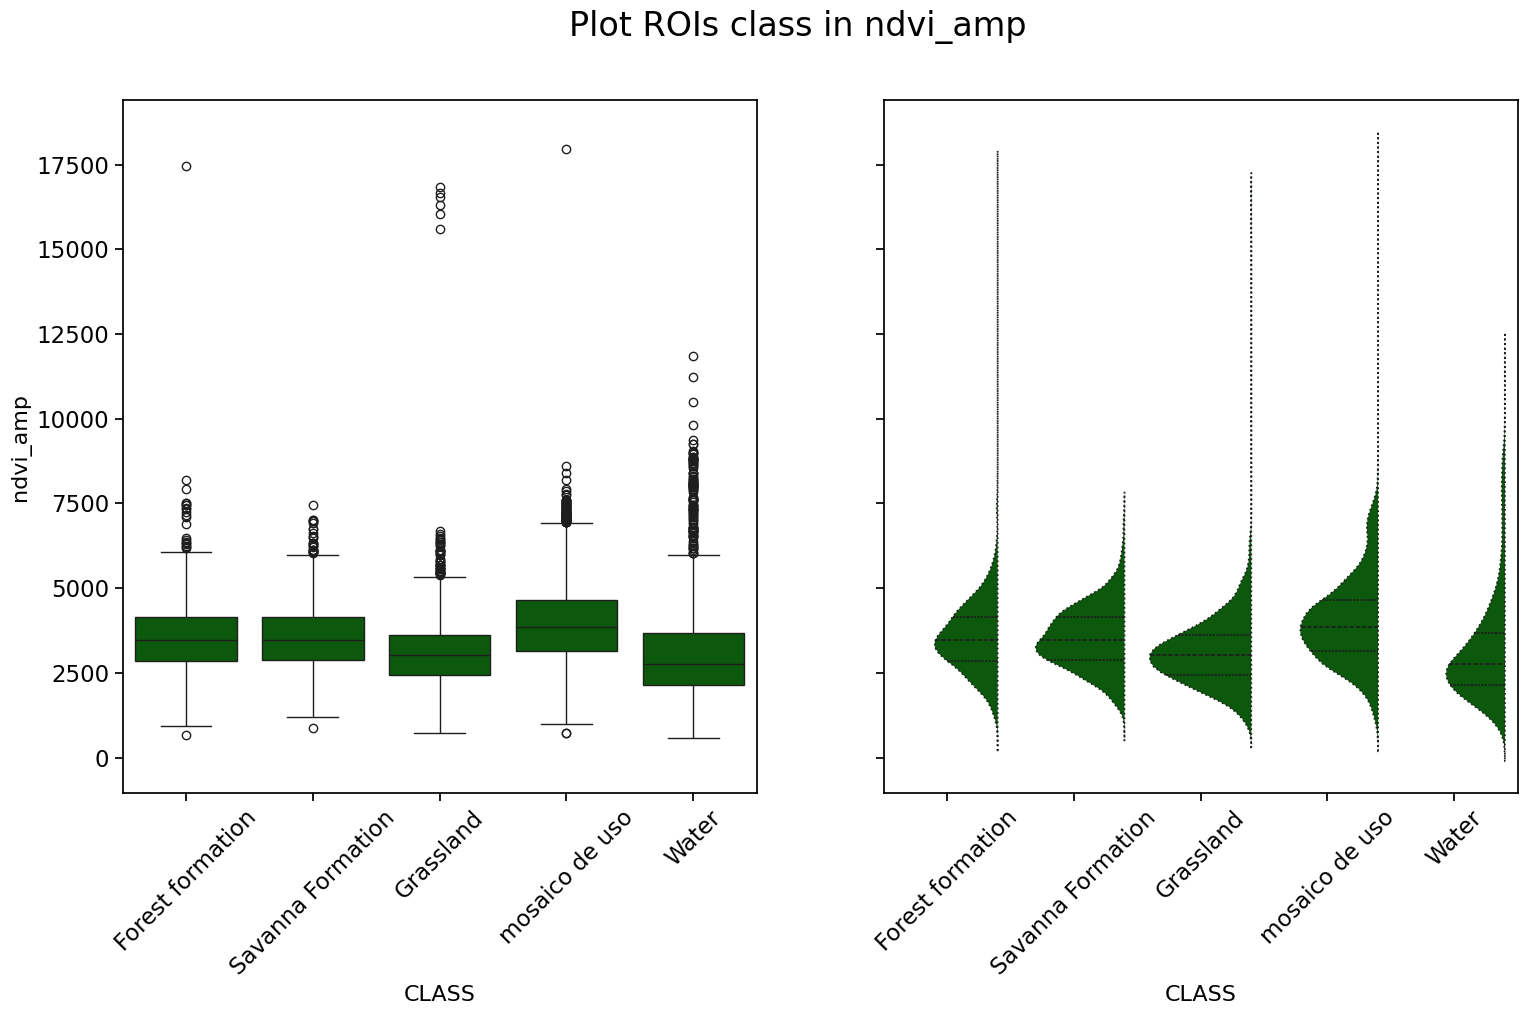

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


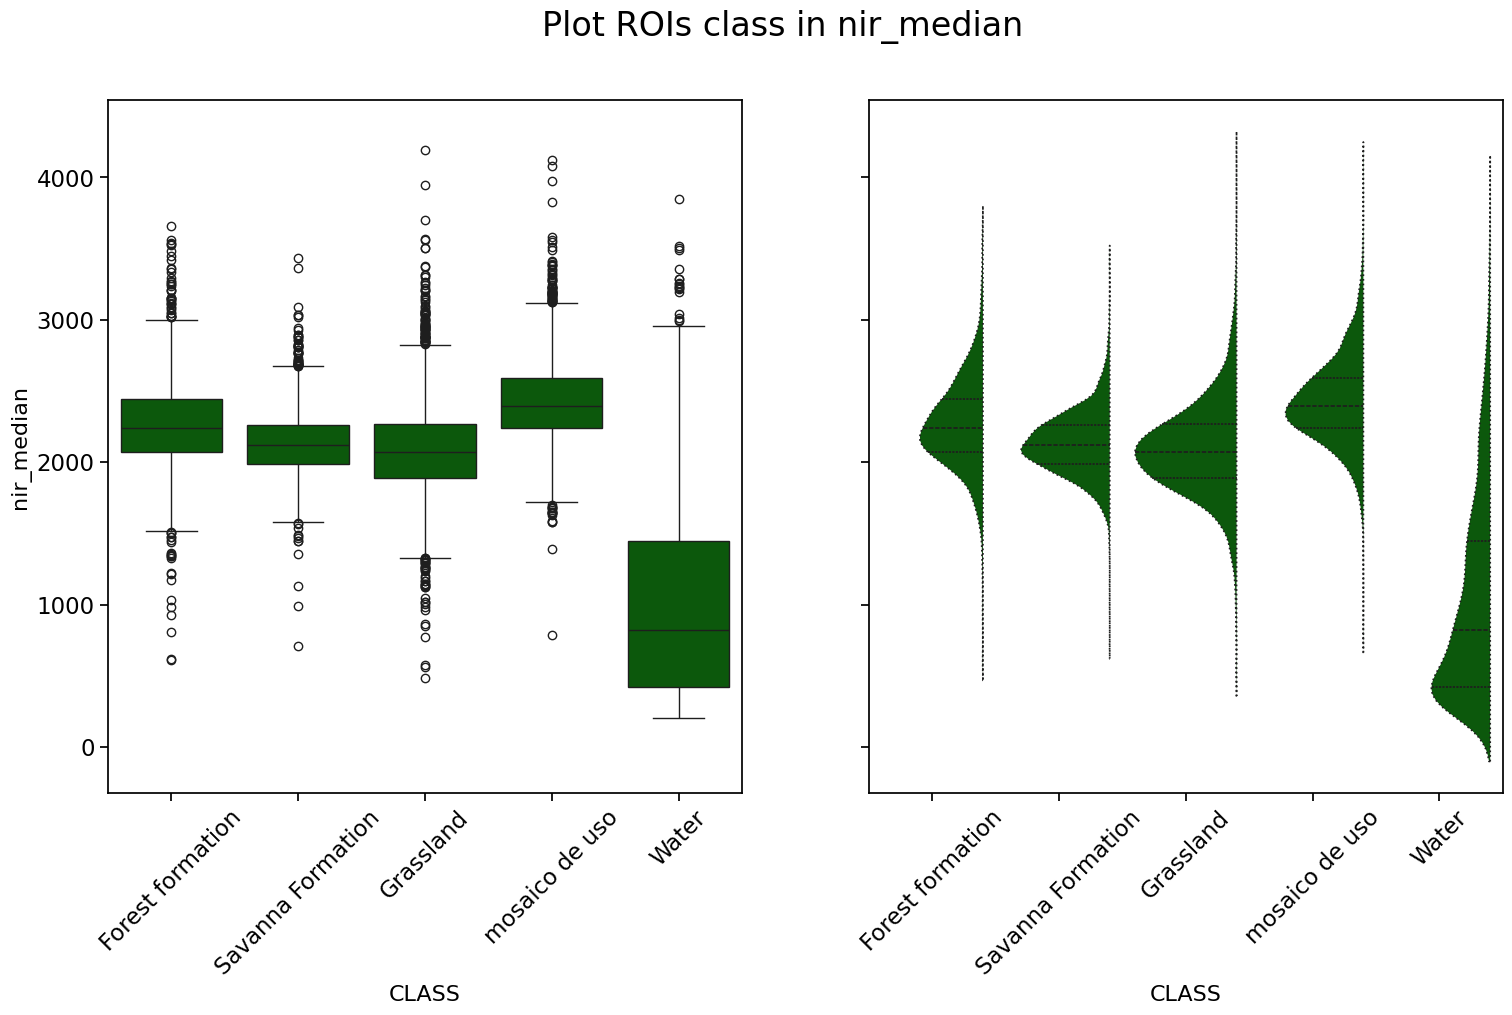

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


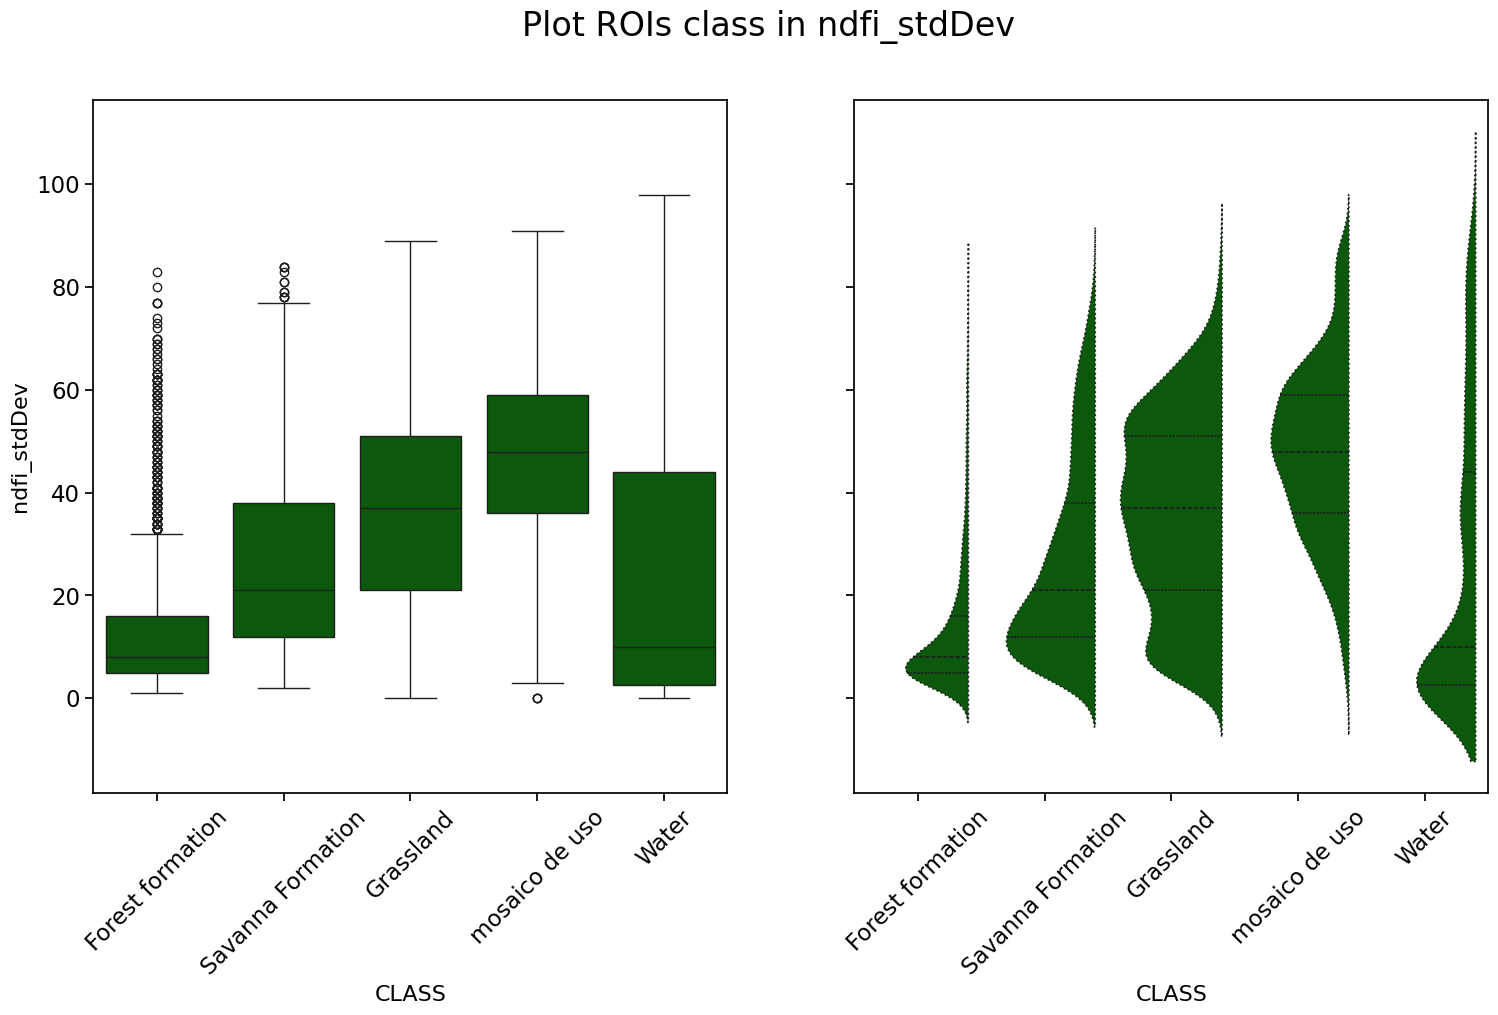

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


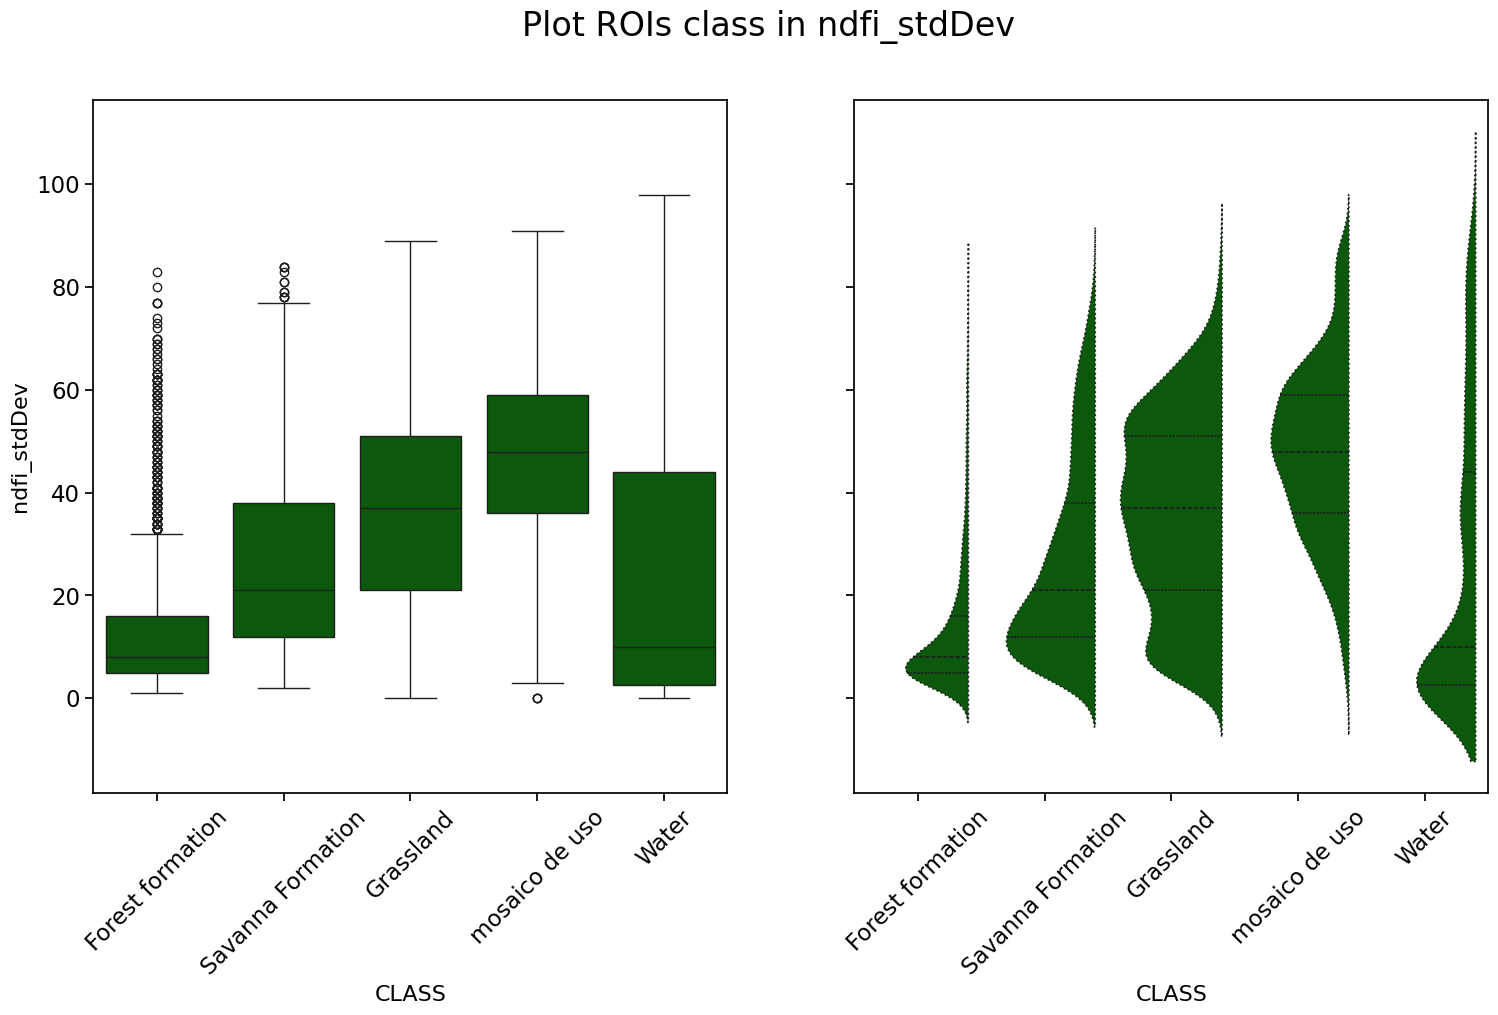

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


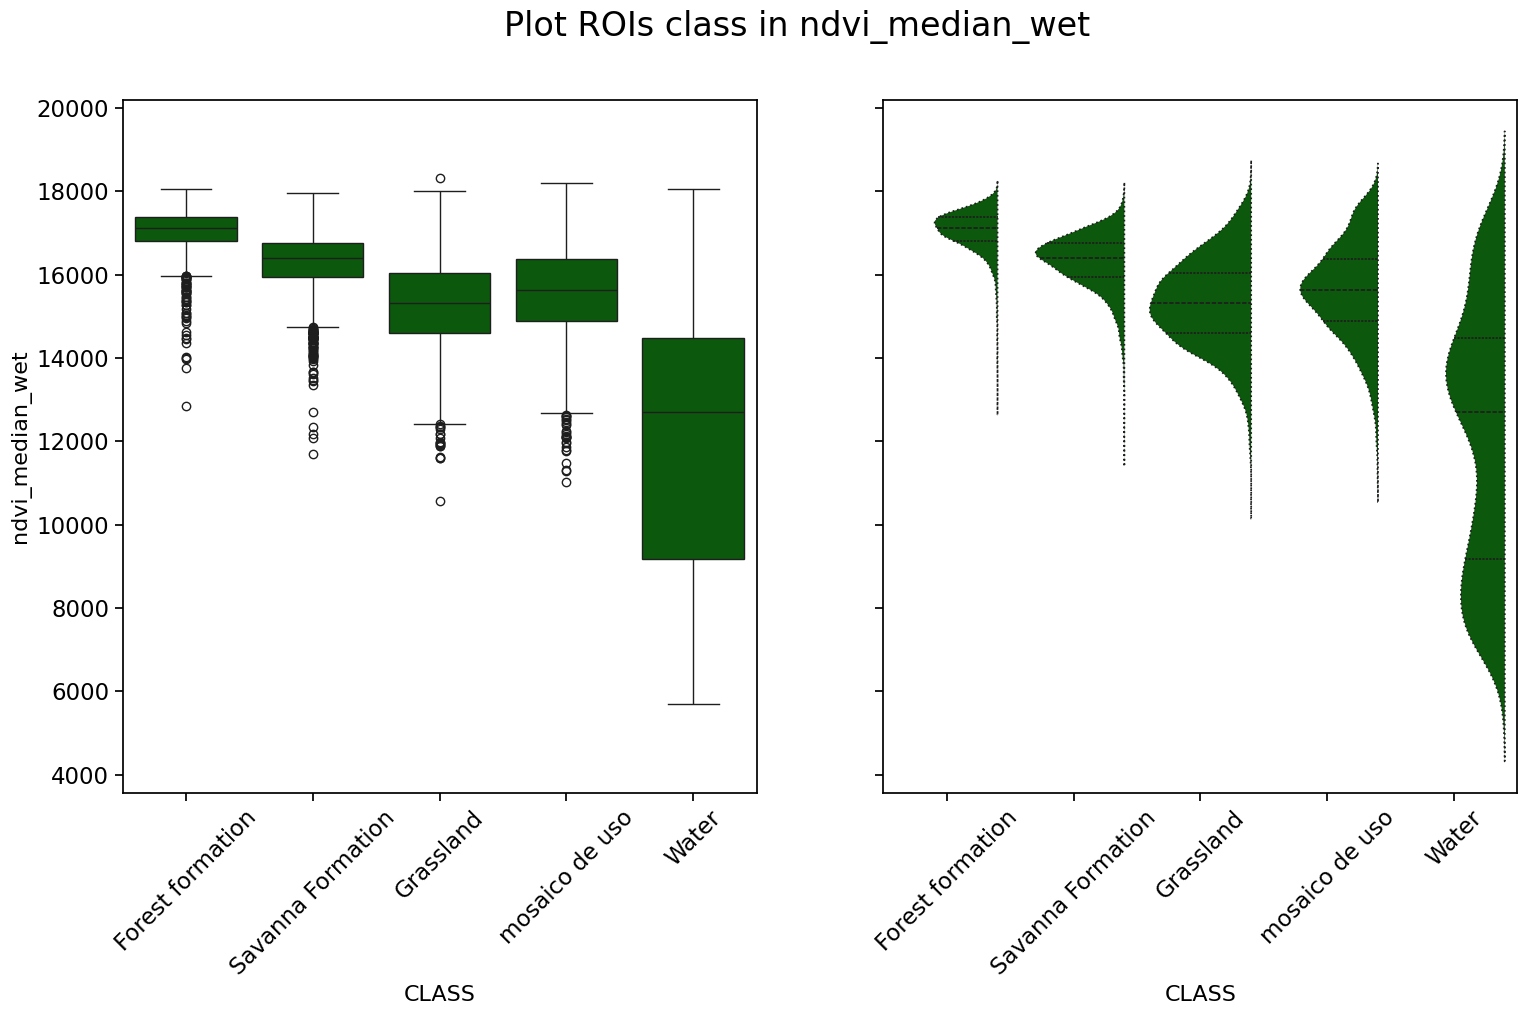

<ipython-input-77-29668d034a03>:7: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ladoB = sns.violinplot(x= classe, y=featA, data=concat_df,ax= axes[1], split=True, linestyle=':',  #  palette="Set3",
<ipython-input-77-29668d034a03>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoA.set_xticklabels(lstCover, rotation=45)
<ipython-input-77-29668d034a03>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ladoB.set_xticklabels(lstCover, rotation=45)


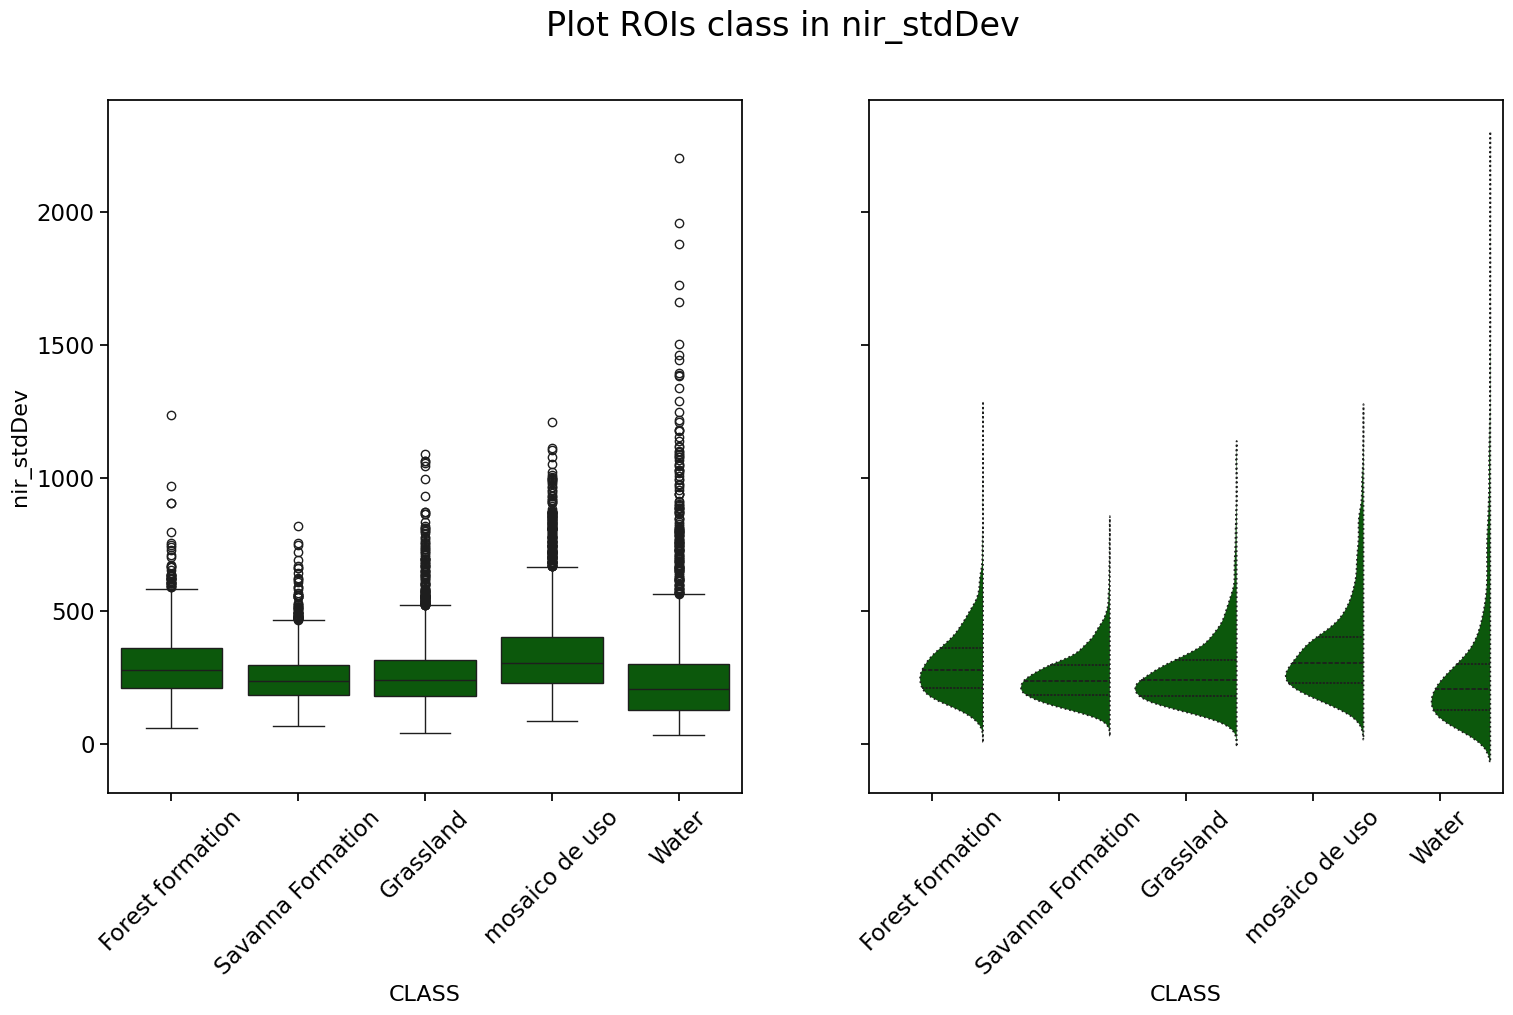

In [ ]:
for ii in range(10):
    numsort = randint(0, len(colunas_index) - 1)
    ploting_violin_rois_Class_index(colunas_index[numsort])

### Analises de Features Selections

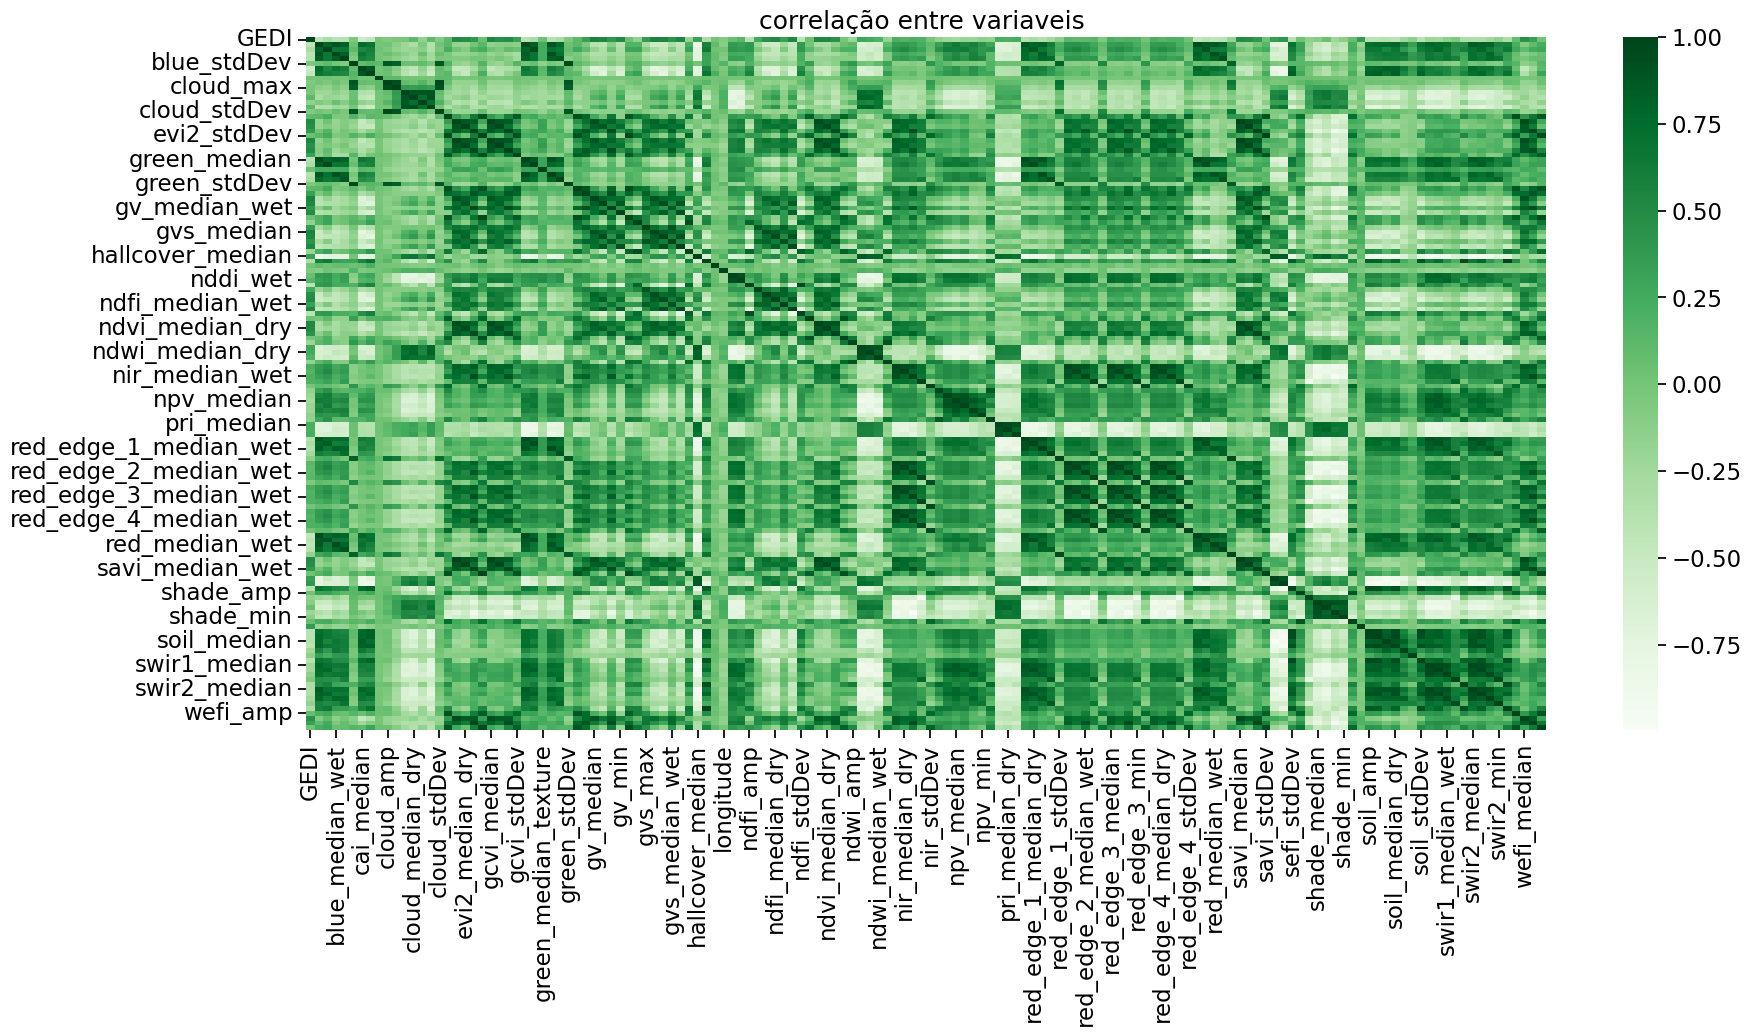

In [ ]:
plt.figure(figsize=(20, 9))
# sns.color_palette("flare", as_cmap=True)
sns.heatmap(concat_df[columns_features].corr(),
           annot= False, fmt= '.2f', cmap= 'Greens')  #
plt.title("correlação entre variaveis " )
plt.show()

### Analises de Features Selection

In [258]:
dfProp = concat_df[classe].value_counts()
dfProp = dfProp.reset_index()
dfProp['prop'] = dfProp['count'].apply(lambda x: round(x/concat_df[classe].shape[0], 2))
dfProp

,reference,count,prop
0,12,3350,0.26
1,4,2933,0.23
2,21,2568,0.20
3,3,2079,0.16
4,33,1943,0.15


In [265]:
X_train, X_test, y_train, y_test = train_test_split(concat_df[columns_features], concat_df[classe], test_size=0.3, random_state=5)

In [267]:
# saber o tamano do conjunto de treino e a sua distribuição
print("size of training set ", X_train.shape)
print(y_train.value_counts())

size of training set  (9011, 144)
reference
12    2331
4     2061
21    1785
3     1438
33    1396
Name: count, dtype: int64


In [264]:
## get rois by class references
# building new dataset by class cover
buildingDF = True
if buildingDF:
    maximoROIs = 4500
    newlstDF = []
    for cclass in [3,4,12,21,33]:
        propCC = dfProp[dfProp['reference'] == cclass]['prop'].values[0]
        tmpDF = concat_df[concat_df[classe] == cclass].sample(n= int(propCC * maximoROIs))
        newlstDF.append(tmpDF)
        print(f" adding {int(propCC * maximoROIs)} samples from class [{cclass}]")

    concDF  = pd.concat(newlstDF, ignore_index=True) #
    print("temos {} filas ".format(concDF.shape))
    concDF.head()
    X_train = concDF[columns_features]
    y_train = concDF[classe]
    print("shape X_train ", X_train.shape)
    print("shape y_train ", y_train.shape)

 adding 720 samples from class [3]
 adding 1035 samples from class [4]
 adding 1170 samples from class [12]
 adding 900 samples from class [21]
 adding 675 samples from class [33]
temos (4500, 145) filas 
shape X_train  (4500, 144)
shape y_train  (4500,)


#### Feature Selection by SelectKBest ANOVA

In [ ]:
# feature extraction
# f_classif  >> Compute the ANOVA F-value for the provided sample.
porcentagemFeat = 0.4
test = SelectKBest(score_func=f_classif, k= porcentagemFeat)

In [ ]:
fit_KBest = test.fit(X_train, y_train)

In [ ]:
# summarize scores
set_printoptions(precision= porcentagemFeat)
print("the first 6 scores ", fit_KBest.scores_[:5])
print("show size of list ", len(fit_KBest.scores_))

[4.8818306637659727e+04 2.4320830158152630e+03 1.9540932499995172e+03
 1.2892303451452940e+03 1.4919579693138537e+03 1.7704816416876987e+01
 2.2561411276112422e+03 1.5932629901611715e+03 1.0670443834117451e+00
 9.0730058285045374e+01 4.8565277018618275e+02 2.5459881072169865e+03
 2.3180321401959368e+03 1.9379638092712910e+03 2.8115891143849881e+03
 1.1478501794114514e+02 8.6435489602216387e+02 3.0058349355550540e+03
 1.9922772662168661e+03 3.4364777599804984e+03 7.8832443233663423e+02
 3.7462243906377457e+03 2.4154634983771998e+03 3.9721198647053584e+03
 9.0774937125567783e+02 3.0617249744136598e+03 2.7636286050240788e+03
 3.1184293178834099e+02 2.0667074837495661e+03 1.8725996931370025e+03
 5.5833860803536012e+01 1.2946890441047060e+03 1.4899379980370431e+03
 1.7873147565027714e+03 1.2988833630746012e+03 1.8912329744201008e+03
 1.0297930800768922e+03 1.1466748115753796e+03 5.9214348038842525e+02
 7.3649963107744043e+02 1.7157502452340223e+03 1.5706410146119017e+03
 1.1699073356519189e

In [ ]:
list_ordenda = copy.deepcopy(fit_KBest.scores_)
list_ordenda =sorted(list_ordenda, reverse= True)
print(list_ordenda)
corte = int(len(list_ordenda) * 0.23)
print(corte)
valor_corte = list_ordenda[corte]
print("corte do core para importancia ", valor_corte)

[48818.30663765973, 7689.095215947629, 6994.514227003128, 5671.770912489856, 5619.192263819371, 5528.747977109547, 5378.590889069917, 5100.859305348039, 4995.1351905437905, 4921.831210957406, 4872.195896094572, 4870.763203390873, 4845.9519433549285, 4819.872224323127, 4805.914212143405, 4762.565667853669, 4694.962724458746, 4645.113792439474, 4571.331891560723, 4536.831955995232, 4440.401001438097, 4423.766414073605, 4286.736347309265, 4256.426037536683, 4245.495837156801, 4170.822504326831, 4069.707085565441, 3972.1198647053584, 3782.714253849142, 3746.2243906377457, 3693.3150341689056, 3588.810224353726, 3584.4616937969554, 3436.4777599804984, 3429.886147993671, 3360.268057222504, 3317.3406879967456, 3278.425838695397, 3238.133203170521, 3207.307549639169, 3157.0741636915636, 3127.744509747785, 3087.571186884299, 3069.271507350815, 3061.7249744136598, 3005.834935555054, 2988.9851473911153, 2967.683460472037, 2965.3577245110355, 2964.0514688340163, 2944.3280215788914, 2920.17210039495

In [ ]:
def print_blocos_5Feat(lst_features):
    text = ''
    for cc, col in enumerate(lst_features):
        text += '"' + str(col) + '",'
        if (cc + 1) % 5 == 0:
            print(text)
            text = ""


In [ ]:
list_feat_kbest = []
for cc, vscore in enumerate(fit_KBest.scores_):
    if vscore > valor_corte:
        list_feat_kbest.append(columns_features[cc])
        print(f"{columns_features[cc]}  <> score {vscore}")


print("\n lista de todas as features importantes pelo KBest \n")
print_blocos_5Feat(list_feat_kbest)
print("\n com {} features".format(len(list_feat_kbest)))

GEDI  <> score 48818.30663765973
gcvi_median  <> score 3746.2243906377457
gcvi_median_wet  <> score 3972.1198647053584
hallcover_median  <> score 4872.195896094572
nddi_dry  <> score 5619.192263819371
nddi_wet  <> score 5528.747977109547
ndwi_median  <> score 4440.401001438097
ndwi_median_dry  <> score 4423.766414073605
nir_median  <> score 4256.426037536683
nir_median_wet  <> score 4069.707085565441
npv_max  <> score 4819.872224323127
npv_median  <> score 4921.831210957406
npv_median_dry  <> score 4845.9519433549285
red_edge_1_median  <> score 4645.113792439474
red_edge_1_median_dry  <> score 4805.914212143405
red_edge_2_median  <> score 4536.831955995232
red_edge_2_median_wet  <> score 4245.495837156801
red_edge_3_median  <> score 4286.736347309265
red_edge_3_median_wet  <> score 4170.822504326831
red_edge_4_median  <> score 4870.763203390873
red_edge_4_median_wet  <> score 4762.565667853669
red_median_dry  <> score 3782.714253849142
savi_median_wet  <> score 3693.3150341689056
shade

#### Gradiente Tree Boost by RFECV feature
https://scikit-learn.org/1.3/auto_examples/feature_selection/plot_rfe_with_cross_validation.html#sphx-glr-auto-examples-feature-selection-plot-rfe-with-cross-validation-py

In [ ]:
# get a list of models to evaluate
def get_models():
    min_features_to_select = 7
    models = dict()
    dictpmt = {}
    count = 0
    for ne in [40, 50, 60, 70]:
        for lr in [0.001, 0.005, 0.01]:
            dictpmt[str(count)] = [ne, lr]
            print(f"# {count + 1} mudando n_estimators= {ne} & learning_rate= {lr}")
            count += 1

    # criando pipeline do modelos gradiente Boosting com varios paramentros
    cv = StratifiedKFold(5)
    for cc in range(count):
        GTBmodel = GradientBoostingClassifier(n_estimators=dictpmt[str(cc)][0], learning_rate= dictpmt[str(cc)][1], max_features= 7)
        rfe = RFECV(
                estimator=GTBmodel,
                step=1,
                cv=cv,
                scoring="accuracy",
                min_features_to_select=min_features_to_select,
                n_jobs=2,
            )

        models[str(cc)] = Pipeline(steps=[('s', rfe),('m', GTBmodel)])
    return models


In [ ]:
# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
    cv = StratifiedKFold(5)
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
    return scores

In [ ]:
# get the models to evaluate
models = get_models()

# 1 mudando n_estimators= 40 & learning_rate= 0.001
# 2 mudando n_estimators= 40 & learning_rate= 0.005
# 3 mudando n_estimators= 40 & learning_rate= 0.01
# 4 mudando n_estimators= 50 & learning_rate= 0.001
# 5 mudando n_estimators= 50 & learning_rate= 0.005
# 6 mudando n_estimators= 50 & learning_rate= 0.01
# 7 mudando n_estimators= 60 & learning_rate= 0.001
# 8 mudando n_estimators= 60 & learning_rate= 0.005
# 9 mudando n_estimators= 60 & learning_rate= 0.01
# 10 mudando n_estimators= 70 & learning_rate= 0.001
# 11 mudando n_estimators= 70 & learning_rate= 0.005
# 12 mudando n_estimators= 70 & learning_rate= 0.01


#1/12 processing model 0
  >0 0.820 (0.133)
#2/12 processing model 1
  >1 0.800 (0.126)
#3/12 processing model 2
  >2 0.800 (0.110)
#4/12 processing model 3
  >3 0.740 (0.150)
#5/12 processing model 4
  >4 0.800 (0.167)
#6/12 processing model 5
  >5 0.760 (0.150)
#7/12 processing model 6
  >6 0.800 (0.141)
#8/12 processing model 7
  >7 0.780 (0.160)
#9/12 processing model 8
  >8 0.760 (0.150)
#10/12 processing model 9
  >9 0.740 (0.150)
#11/12 processing model 10
  >10 0.800 (0.141)
#12/12 processing model 11
  >11 0.820 (0.098)


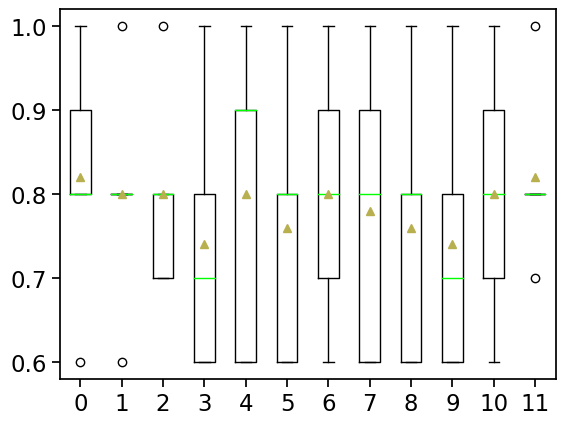

In [ ]:
# evaluate the models and store results
results, names = list(), list()
count = 1
for name, model in models.items():
    print(f"#{count}/{len(models.items())} processing model {name}")
    scores = evaluate_model(model, X_train[conjFeature], y_train)
    results.append(scores)
    names.append(name)
    print('  >%s %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))
    count += 1
# plot model performance for comparison
plt.boxplot(results, labels=names, showmeans=True)
plt.show()

In [213]:
melhorModel = '0'

In [ ]:
type(models.items())

dict_items

#### testando com um unico conjunto de paramentros para o modelo

In [ ]:
import time
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import RFECV


In [ ]:
lstFeatSelect = None
deafutModel = False
conjFeature = []
# fixar o número de variaveis
fixarNFeat = True
# número máximo de variaveis para o modelo das 144
numMin = 50

In [268]:
# otimizado seria para rodar o modelo com variaveis que ele determinou que seriam ótimas
otimizado = False
if otimizado:
    conjFeature = copy.deepcopy(lstFeatSelect)
    fixarNFeat = False
else:
    conjFeature = copy.deepcopy(columns_features)

print(f"we have {len(conjFeature)} feature now")
print("show the first feature => ", conjFeature[0])

we have 144 feature now
show the first feature =>  GEDI


In [ ]:
if deafutModel:
    GTBmodel = GradientBoostingClassifier(n_estimators=40, learning_rate= 0.001, max_features= 7, random_state=42)
else:
    print("selecionando o modelo anteriormente com melhor desempenho")
    GTBmodel = copy.deepcopy(models[melhorModel][1])
    print(GTBmodel)

start = time.time()
min_features_to_select =  7 # Minimum number of features to consider
cv = StratifiedKFold(5)
rfecv = RFECV(
    estimator=GTBmodel,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=2,
)
rfecv.fit(X_train[conjFeature], y_train)
print(f"Optimal number of features: {rfecv.n_features_}")

end = time.time()
tiempo = end - start
if tiempo < 60:
    print(f"model trained in {tiempo} seconds")
else:
    print(f"model trained in {tiempo/60} minutos")

selecionando o modelo anteriormente com melhor desempenho
GradientBoostingClassifier(learning_rate=0.001, max_features=7, n_estimators=40)


In [225]:
# criando um dataframe com os resultados
cv_results = pd.DataFrame(rfecv.cv_results_) # , index= rfecv.get_feature_names_out()
print("colunas cv_results ", cv_results.columns)
print(cv_results.shape)
print(cv_results.head(3))

colunas cv_results  Index(['mean_test_score', 'std_test_score', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score'],
      dtype='object')
(33, 7)
   mean_test_score  std_test_score  split0_test_score  split1_test_score  \
0             0.82        0.074833                0.9                0.8   
1             0.84        0.101980                1.0                0.7   
2             0.82        0.132665                1.0                0.6   

   split2_test_score  split3_test_score  split4_test_score  
0                0.9                0.8                0.7  
1                0.9                0.8                0.8  
2                0.9                0.8                0.8  


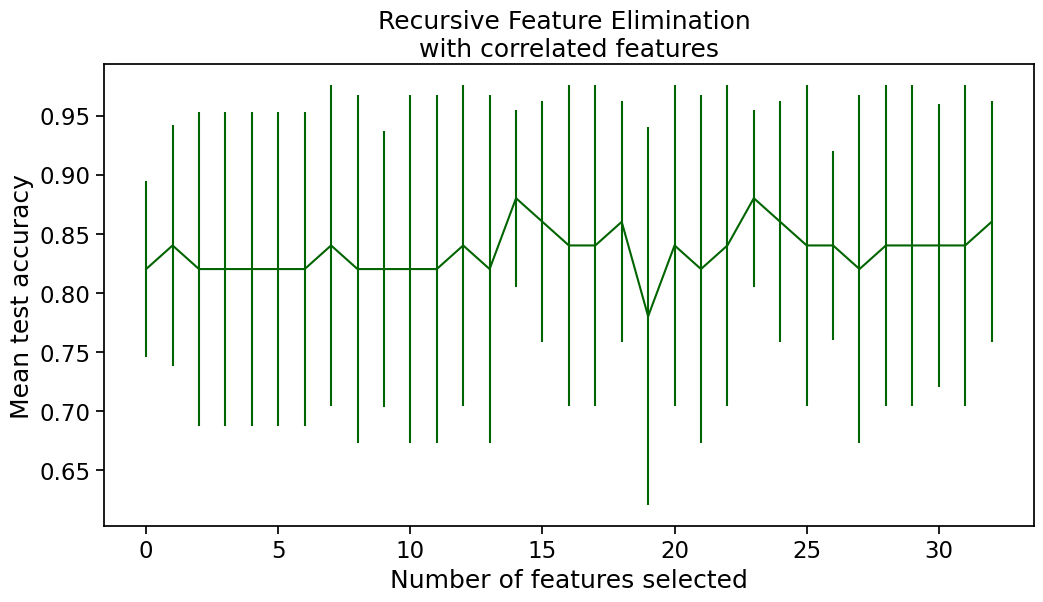

In [226]:
plt.figure(figsize=(12, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x= cv_results.index,
    y= cv_results["mean_test_score"],
    yerr= cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

https://scikit-learn.org/1.3/auto_examples/feature_selection/plot_rfe_with_cross_validation.html#sphx-glr-auto-examples-feature-selection-plot-rfe-with-cross-validation-py
From the plot above one can further notice a plateau of equivalent scores (similar mean value and overlapping errorbars) for 3 to 5 selected features. This is the result of introducing correlated features. Indeed, the optimal model selected by the RFE can lie within this range, depending on the cross-validation technique. The test accuracy decreases above 5 selected features, this is, keeping non-informative features leads to over-fitting and is therefore detrimental for the statistical performance of the models.

In [219]:
rfecv.ranking_

array([ 1,  1, 10,  9,  1,  6,  1,  1,  1,  1,  2,  1,  8,  1,  1,  1,  7,
        4,  1,  1,  1,  1,  1,  3,  1,  5,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [227]:
lst_ranking = [(kk, cc) for cc, kk in enumerate(rfecv.ranking_) if kk < 2]
print("quantos features otimos ", len(lst_ranking))

if fixarNFeat:
    numbNotOti = numMin - len(lst_ranking)
    print(f"Addicionando << {numbNotOti} >> features a mais não ótimas ")
    lst_ranking = [(kk, cc) for cc, kk in enumerate(rfecv.ranking_) if kk < numbNotOti]
    print("quantos features otimos ", len(lst_ranking))

lstFeatSelect = []
count = 1
for kk, cc in lst_ranking:
    print(f"# {count} ranking {kk} | pos {cc} >> feature >> {conjFeature[cc]}")
    lstFeatSelect.append(conjFeature[cc])
    count += 1


quantos features otimos  21
# 1 ranking 1 | pos 0 >> feature >> GEDI
# 2 ranking 1 | pos 1 >> feature >> blue_median_wet
# 3 ranking 1 | pos 4 >> feature >> gcvi_median_wet
# 4 ranking 1 | pos 8 >> feature >> gvs_min
# 5 ranking 1 | pos 10 >> feature >> latitude
# 6 ranking 1 | pos 12 >> feature >> ndwi_amp
# 7 ranking 1 | pos 17 >> feature >> red_edge_1_median
# 8 ranking 1 | pos 18 >> feature >> red_edge_1_median_dry
# 9 ranking 1 | pos 19 >> feature >> red_edge_1_median_wet
# 10 ranking 1 | pos 21 >> feature >> red_edge_2_median
# 11 ranking 1 | pos 22 >> feature >> red_edge_2_median_wet
# 12 ranking 1 | pos 23 >> feature >> red_edge_3_median
# 13 ranking 1 | pos 25 >> feature >> red_edge_4_median
# 14 ranking 1 | pos 26 >> feature >> red_edge_4_median_wet
# 15 ranking 1 | pos 27 >> feature >> red_median_dry
# 16 ranking 1 | pos 28 >> feature >> red_median_wet
# 17 ranking 1 | pos 30 >> feature >> savi_stdDev
# 18 ranking 1 | pos 31 >> feature >> shade_median
# 19 ranking 1 | pos 33

In [250]:
print(len(lst_ranking))
print(len(lstFeatSel))

21

In [252]:
# só rodar se vai salvar a tabela
saveResult = True
lstRanking = []
lstFeatSel = []
if saveResult:
    for kk, cc in lst_ranking:
        print(f"# {count} ranking {kk} | pos {cc} >> feature >> {conjFeature[cc]}")
        lstRanking.append(kk)
        lstFeatSel.append(conjFeature[cc])
        count += 1
    dict_result= {
        'ranking': lstRanking,
        'features': lstFeatSel
    }
    dfresult = pd.DataFrame.from_dict(dict_result)
    path_name_file = pathBase + '/features_selected_S2_2022.csv'
    dfresult.to_csv(path_name_file, index= False)

    print("tabela salva em pasta do drive")

# 64 ranking 1 | pos 0 >> feature >> GEDI
# 65 ranking 1 | pos 1 >> feature >> blue_median_wet
# 66 ranking 1 | pos 4 >> feature >> gcvi_median_wet
# 67 ranking 1 | pos 8 >> feature >> gvs_min
# 68 ranking 1 | pos 10 >> feature >> latitude
# 69 ranking 1 | pos 12 >> feature >> ndwi_amp
# 70 ranking 1 | pos 17 >> feature >> red_edge_1_median
# 71 ranking 1 | pos 18 >> feature >> red_edge_1_median_dry
# 72 ranking 1 | pos 19 >> feature >> red_edge_1_median_wet
# 73 ranking 1 | pos 21 >> feature >> red_edge_2_median
# 74 ranking 1 | pos 22 >> feature >> red_edge_2_median_wet
# 75 ranking 1 | pos 23 >> feature >> red_edge_3_median
# 76 ranking 1 | pos 25 >> feature >> red_edge_4_median
# 77 ranking 1 | pos 26 >> feature >> red_edge_4_median_wet
# 78 ranking 1 | pos 27 >> feature >> red_median_dry
# 79 ranking 1 | pos 28 >> feature >> red_median_wet
# 80 ranking 1 | pos 30 >> feature >> savi_stdDev
# 81 ranking 1 | pos 31 >> feature >> shade_median
# 82 ranking 1 | pos 33 >> feature >> slop

In [ ]:
columns_features[127]

'soil_median_wet'

#### testing accuracy of paramater set to model selected

In [234]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [244]:
X_train[conjFeature].shape

(50, 39)

In [246]:
y_train.value_counts()

,count
reference,
3,10
4,10
12,10
21,10
33,10


In [247]:
X_test.shape

(12616, 144)

In [235]:
# ajusta o modelos com o conjunto de treinamento
GTBmodel.fit(X_train[conjFeature], y_train)

#########################################################
# faz o predict com as amostras de teste ou validação  ##
y_pred = GTBmodel.predict(X_test[conjFeature])

In [236]:
matrixConf = confusion_matrix(y_test, y_pred)
matrixConf

array([[1765,  167,   28,    8,   78],
       [ 543, 1867,  246,  178,   26],
       [  46,   66, 1981,  961,  230],
       [  33,   28,  264, 2189,    7],
       [  29,   11,  233,   48, 1584]])

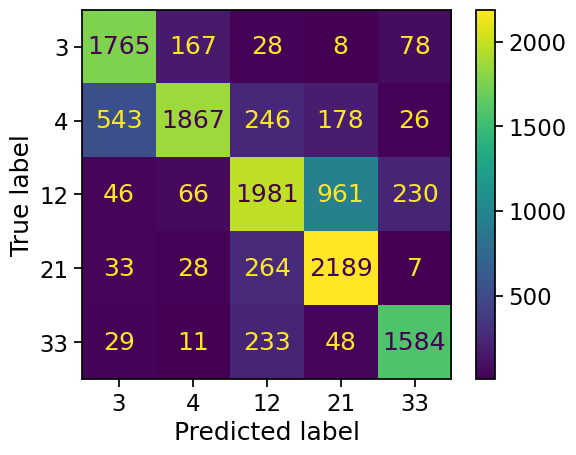

In [237]:
disp = ConfusionMatrixDisplay(confusion_matrix=matrixConf, display_labels= GTBmodel.classes_)
disp.plot()
plt.show()

In [241]:
matrixConfNorm = confusion_matrix(y_test, y_pred, normalize='true')
print(type(matrixConfNorm))

<class 'numpy.ndarray'>


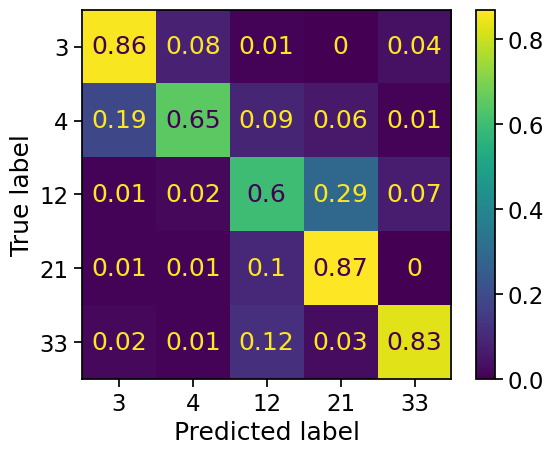

In [242]:
matrixConfNorm = confusion_matrix(y_test, y_pred, normalize='true')
matrixConfNorm = np.round(matrixConfNorm, 2)
disp = ConfusionMatrixDisplay(
            confusion_matrix= matrixConfNorm,
            display_labels= GTBmodel.classes_
            )
disp.plot()
plt.show()

### Tuning hyper-paramter

In [ ]:
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
param_grid = {
    "n_estimators": [40, 50, 60, 70],
    "learning_rate": [0.001, 0.005, 0.01]
}
search = HalvingGridSearchCV(GTBmodel, param_grid,
                            resource='n_estimators',
                            max_resources= 10,
                            random_state=0).fit(X_train[conjFeature], y_train)
print("show the better parameters ", search.best_params_  )
# example {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 9}

In [ ]:
# para implementar
# https://scikit-learn.org/1.1/auto_examples/model_selection/plot_successive_halving_iterations.html#sphx-glr-auto-examples-model-selection-plot-successive-halving-iterations-py